In [1]:
# from google.colab import drive

# drive.mount("/content/drive")

print("Local environment ready.")

Local environment ready.


In [3]:
# Install the libraries needed for the interactive dashboard

%pip install -q plotly

# Import the required libraries

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import display, HTML

print("All libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
All libraries imported successfully.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Main TDW project folder in Google Drive

PROJECT_DIR = Path(".")

# Figures will be saved directly inside TDW_2/figures

FIGURES_DIR = PROJECT_DIR / "figures"

# Create the figures folder automatically if it does not already exist

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Dataset locations

QUARTERLY_FILE = PROJECT_DIR / "cleaned_lfs_qtr_state.csv"
GENDER_FILE = PROJECT_DIR / "cleaned_lfs_state_sex.csv"

# Check whether the files exist

if not QUARTERLY_FILE.exists():
    raise FileNotFoundError(
        "cleaned_lfs_qtr_state.csv was not found inside TDW_2."
    )

if not GENDER_FILE.exists():
    raise FileNotFoundError(
        "cleaned_lfs_state_sex.csv was not found inside TDW_2."
    )

print("Project folder:", PROJECT_DIR)
print("Figures folder:", FIGURES_DIR)
print("Both cleaned datasets were found successfully.")

Project folder: .
Figures folder: figures
Both cleaned datasets were found successfully.


In [5]:
# Load both cleaned datasets

df_qtr = pd.read_csv(
    QUARTERLY_FILE,
    parse_dates=["date"]
)

df_gender = pd.read_csv(
    GENDER_FILE,
    parse_dates=["date"]
)

# Arrange records in chronological order

df_qtr = df_qtr.sort_values(
    ["state", "date"]
).reset_index(drop=True)

df_gender = df_gender.sort_values(
    ["state", "sex", "date"]
).reset_index(drop=True)

print("Datasets loaded successfully.")

print("\nQuarterly dataset shape:", df_qtr.shape)
print("Gender dataset shape:", df_gender.shape)

print("\nQuarterly dataset preview:")
display(df_qtr.head())

print("\nGender dataset preview:")
display(df_gender.head())

Datasets loaded successfully.

Quarterly dataset shape: (560, 15)
Gender dataset shape: (1732, 13)

Quarterly dataset preview:


,date,state,lf,lf_employed,lf_unemployed,lf_outside,p_rate,u_rate,quarter_period,year,quarter,region,qoq_change_pp,yoy_change_pp,state_rank_qtr
0,2017-01-01,Johor,1685.8,1634.6,51.2,816.9,67.4,3.0,2017Q1,2017,1,Southern,NaN,NaN,7
1,2017-04-01,Johor,1675.2,1616.0,59.2,823.5,67.0,3.5,2017Q2,2017,2,Southern,0.5,NaN,10
2,2017-07-01,Johor,1675.4,1607.7,67.7,830.7,66.9,4.0,2017Q3,2017,3,Southern,0.5,NaN,12
3,2017-10-01,Johor,1684.4,1632.6,51.8,825.4,67.1,3.1,2017Q4,2017,4,Southern,-0.9,NaN,9
4,2018-01-01,Johor,1740.3,1691.7,48.6,784.8,68.9,2.8,2018Q1,2018,1,Southern,-0.3,-0.2,7



Gender dataset preview:


,state,sex,date,lf,lf_employed,lf_unemployed,lf_outside,p_rate,u_rate,ep_ratio,year,region,implied_ep_ratio
0,Johor,both,1982-01-01,653.1,630.2,22.9,345.1,65.4,3.5,63.4,1982,Southern,63.1
1,Johor,both,1983-01-01,650.9,623.7,27.2,344.1,65.4,4.2,60.5,1983,Southern,62.7
2,Johor,both,1984-01-01,688.2,657.3,30.9,372.1,64.9,4.5,61.7,1984,Southern,62.0
3,Johor,both,1985-01-01,710.4,672.7,37.6,354.7,66.7,5.3,61.2,1985,Southern,63.2
4,Johor,both,1986-01-01,751.2,700.4,50.8,367.8,67.1,6.8,61.7,1986,Southern,62.6


In [6]:
# Required columns for the quarterly dataset

required_qtr_columns = {
    "date",
    "state",
    "lf",
    "lf_employed",
    "lf_unemployed",
    "lf_outside",
    "p_rate",
    "u_rate",
    "year",
    "quarter",
    "region",
    "qoq_change_pp",
    "yoy_change_pp",
    "state_rank_qtr"
}

# Required columns for the gender dataset

required_gender_columns = {
    "date",
    "state",
    "sex",
    "lf",
    "lf_employed",
    "lf_unemployed",
    "lf_outside",
    "p_rate",
    "u_rate",
    "ep_ratio",
    "year",
    "region",
    "implied_ep_ratio"
}

missing_qtr = required_qtr_columns - set(df_qtr.columns)
missing_gender = required_gender_columns - set(df_gender.columns)

if missing_qtr:
    raise ValueError(
        f"Missing quarterly columns: {sorted(missing_qtr)}"
    )

if missing_gender:
    raise ValueError(
        f"Missing gender columns: {sorted(missing_gender)}"
    )

print("DATA VALIDATION SUCCESSFUL")
print("=" * 50)

print("Quarterly records:", len(df_qtr))
print("States and federal territories:", df_qtr["state"].nunique())

print(
    "Quarterly period:",
    df_qtr["date"].min().to_period("Q"),
    "to",
    df_qtr["date"].max().to_period("Q")
)

print("\nGender records:", len(df_gender))
print("Gender categories:", sorted(df_gender["sex"].unique()))

print(
    "Gender period:",
    df_gender["year"].min(),
    "to",
    df_gender["year"].max()
)

print("\nThe data is ready for visualisation.")

DATA VALIDATION SUCCESSFUL
Quarterly records: 560
States and federal territories: 16
Quarterly period: 2017Q1 to 2025Q3

Gender records: 1732
Gender categories: ['both', 'female', 'male']
Gender period: 1982 to 2023

The data is ready for visualisation.


In [7]:
def save_and_show_figure(filename):
    """
    Save the current Matplotlib figure as a high-quality PNG
    inside the TDW_2/figures folder, display it, and close it.
    """

    if not filename.lower().endswith(".png"):
        filename = filename + ".png"

    save_path = FIGURES_DIR / filename

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close()

    print(f"Figure saved successfully: {save_path}")

In [8]:
save_and_show_figure("01_unemployment_rate_distribution")

<Figure size 640x480 with 0 Axes>

Figure saved successfully: figures\01_unemployment_rate_distribution.png


In [9]:
# Set a consistent professional style for all visualisations

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print("Visualisation style configured successfully.")

Visualisation style configured successfully.


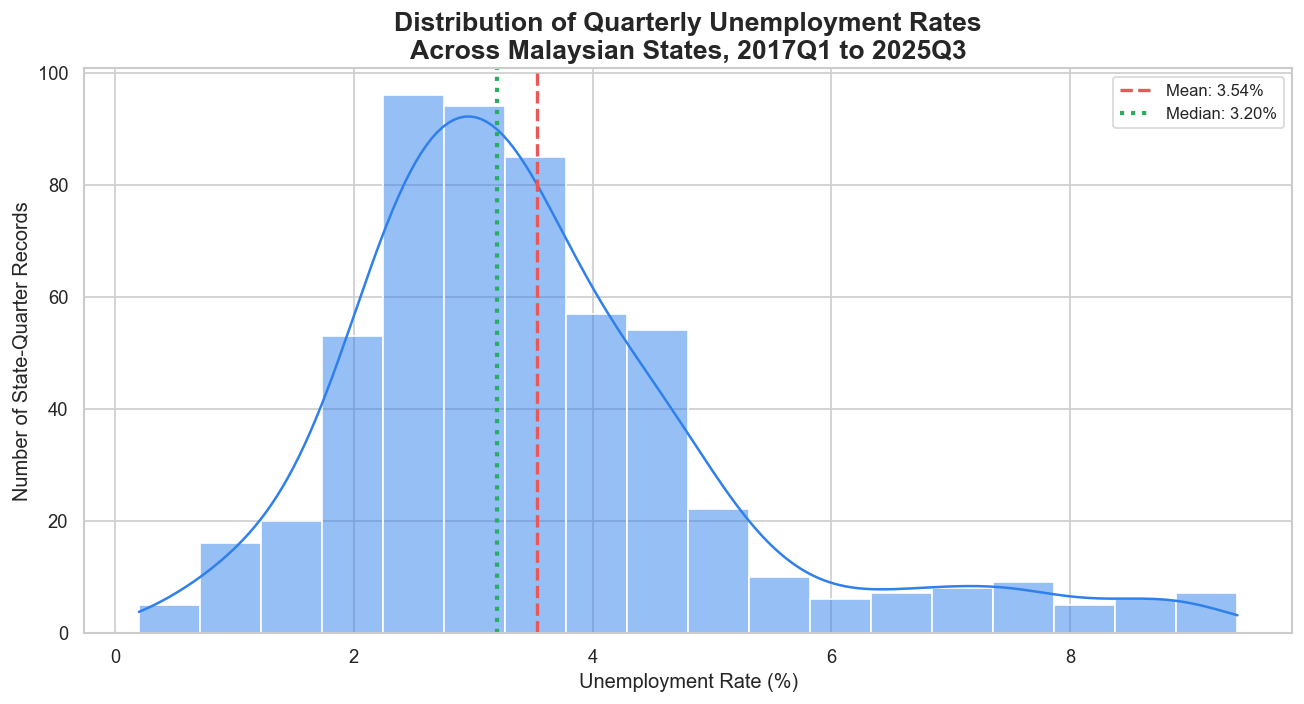

Figure saved successfully: figures\01_unemployment_rate_distribution.png


In [10]:
# FIGURE 1: Distribution of quarterly unemployment rates

mean_rate = df_qtr["u_rate"].mean()
median_rate = df_qtr["u_rate"].median()

start_period = df_qtr["date"].min().to_period("Q")
end_period = df_qtr["date"].max().to_period("Q")

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df_qtr,
    x="u_rate",
    bins=18,
    kde=True,
    color="#2F80ED",
    edgecolor="white",
    linewidth=1
)

# Add mean and median reference lines

plt.axvline(
    mean_rate,
    color="#EB5757",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_rate:.2f}%"
)

plt.axvline(
    median_rate,
    color="#27AE60",
    linestyle=":",
    linewidth=2.5,
    label=f"Median: {median_rate:.2f}%"
)

plt.title(
    "Distribution of Quarterly Unemployment Rates\n"
    f"Across Malaysian States, {start_period} to {end_period}",
    fontweight="bold"
)

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Number of State-Quarter Records")

plt.legend()
plt.tight_layout()

save_and_show_figure(
    "01_unemployment_rate_distribution"
)

In [11]:
# Automatically calculate the important findings for Figure 1

minimum_rate = df_qtr["u_rate"].min()
maximum_rate = df_qtr["u_rate"].max()
standard_deviation = df_qtr["u_rate"].std()
skewness = df_qtr["u_rate"].skew()

print("FIGURE 1 FINDINGS")
print("=" * 50)

print(f"Mean unemployment rate: {mean_rate:.2f}%")
print(f"Median unemployment rate: {median_rate:.2f}%")
print(f"Minimum unemployment rate: {minimum_rate:.2f}%")
print(f"Maximum unemployment rate: {maximum_rate:.2f}%")
print(f"Standard deviation: {standard_deviation:.2f}")
print(f"Distribution skewness: {skewness:.2f}")

if skewness > 0.5:
    print(
        "\nInterpretation: The distribution is positively skewed. "
        "Most state-quarter unemployment rates are concentrated at "
        "lower values, while several unusually high rates extend the "
        "distribution towards the right."
    )
elif skewness < -0.5:
    print(
        "\nInterpretation: The distribution is negatively skewed. "
        "Most observations are concentrated at higher unemployment rates."
    )
else:
    print(
        "\nInterpretation: The unemployment-rate distribution is "
        "approximately balanced around its centre."
    )

FIGURE 1 FINDINGS
Mean unemployment rate: 3.54%
Median unemployment rate: 3.20%
Minimum unemployment rate: 0.20%
Maximum unemployment rate: 9.40%
Standard deviation: 1.63
Distribution skewness: 1.28

Interpretation: The distribution is positively skewed. Most state-quarter unemployment rates are concentrated at lower values, while several unusually high rates extend the distribution towards the right.


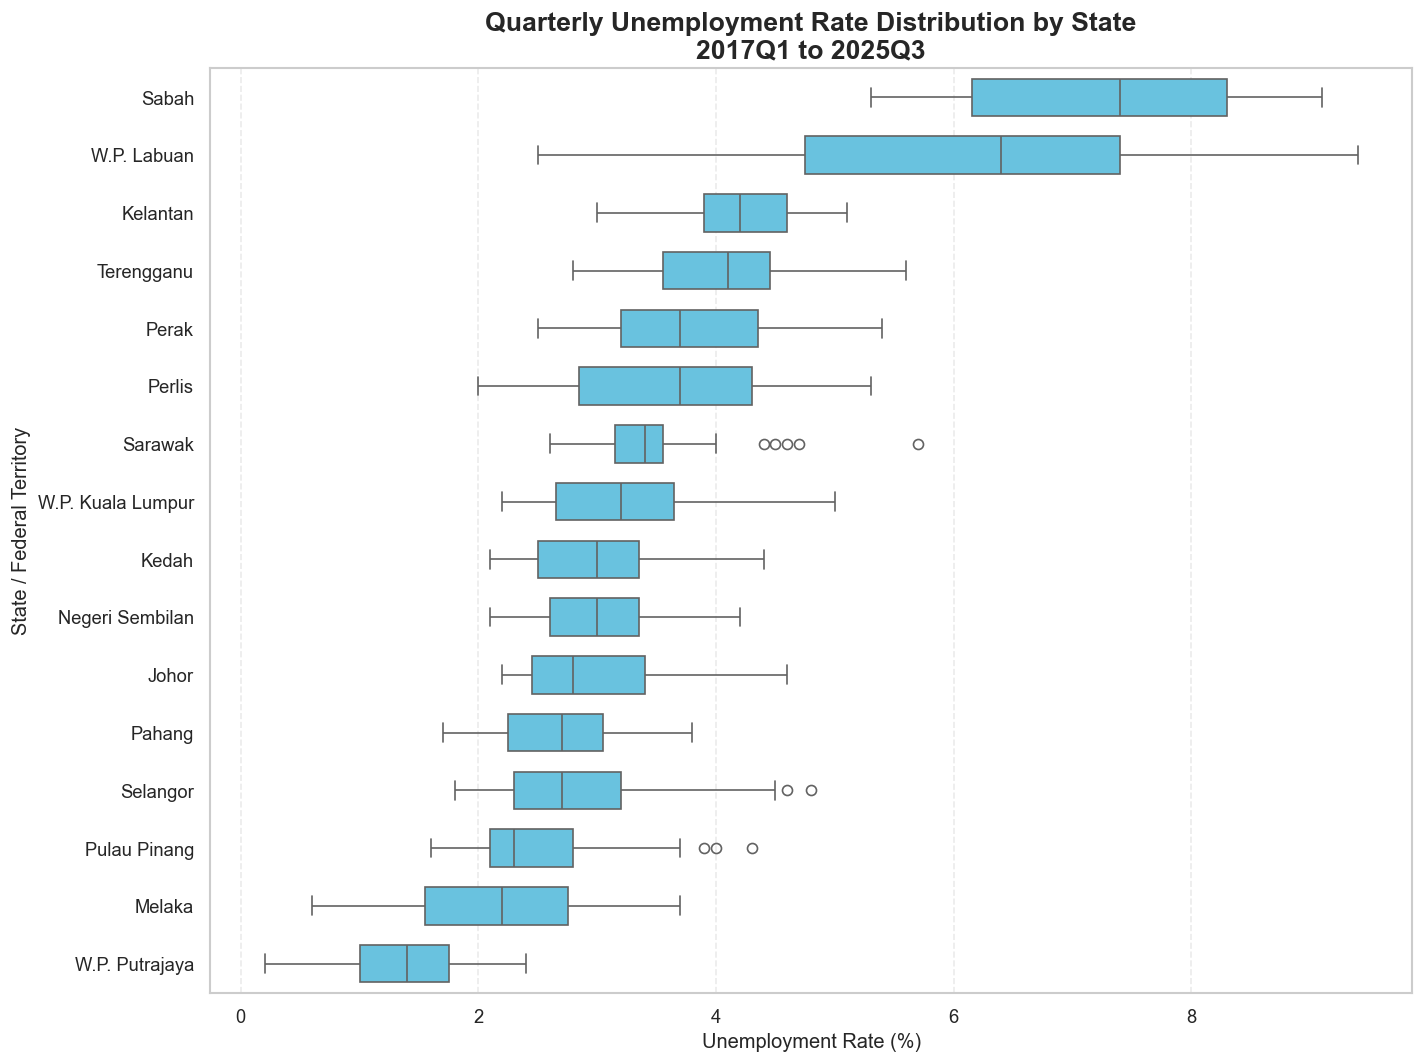

Figure saved successfully: figures\02_unemployment_rate_boxplot_by_state.png


In [12]:
# FIGURE 2: Distribution of unemployment rates by state

# Arrange states from highest to lowest median unemployment rate

state_order = (
    df_qtr.groupby("state")["u_rate"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 9))

sns.boxplot(
    data=df_qtr,
    x="u_rate",
    y="state",
    order=state_order,
    color="#56CCF2",
    width=0.65,
    showfliers=True
)

plt.title(
    "Quarterly Unemployment Rate Distribution by State\n"
    f"{df_qtr['date'].min().to_period('Q')} to "
    f"{df_qtr['date'].max().to_period('Q')}",
    fontweight="bold"
)

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State / Federal Territory")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

save_and_show_figure(
    "02_unemployment_rate_boxplot_by_state"
)

In [13]:
# Calculate the important findings for Figure 2

state_statistics = (
    df_qtr.groupby("state")["u_rate"]
    .agg(
        median_rate="median",
        mean_rate="mean",
        minimum_rate="min",
        maximum_rate="max",
        standard_deviation="std"
    )
    .sort_values("median_rate", ascending=False)
)

highest_median_state = state_statistics.index[0]
lowest_median_state = state_statistics.index[-1]

most_variable_state = (
    state_statistics["standard_deviation"].idxmax()
)

least_variable_state = (
    state_statistics["standard_deviation"].idxmin()
)

print("FIGURE 2 FINDINGS")
print("=" * 60)

print(
    f"Highest median unemployment rate: "
    f"{highest_median_state} "
    f"({state_statistics.loc[highest_median_state, 'median_rate']:.2f}%)"
)

print(
    f"Lowest median unemployment rate: "
    f"{lowest_median_state} "
    f"({state_statistics.loc[lowest_median_state, 'median_rate']:.2f}%)"
)

print(
    f"Most variable unemployment rate: "
    f"{most_variable_state} "
    f"(SD = "
    f"{state_statistics.loc[most_variable_state, 'standard_deviation']:.2f})"
)

print(
    f"Most stable unemployment rate: "
    f"{least_variable_state} "
    f"(SD = "
    f"{state_statistics.loc[least_variable_state, 'standard_deviation']:.2f})"
)

print("\nState statistics:")
display(state_statistics.round(2))

FIGURE 2 FINDINGS
Highest median unemployment rate: Sabah (7.40%)
Lowest median unemployment rate: W.P. Putrajaya (1.40%)
Most variable unemployment rate: W.P. Labuan (SD = 1.81)
Most stable unemployment rate: Negeri Sembilan (SD = 0.49)

State statistics:


,median_rate,mean_rate,minimum_rate,maximum_rate,standard_deviation
state,,,,,
Sabah,7.4,7.21,5.3,9.1,1.26
W.P. Labuan,6.4,6.18,2.5,9.4,1.81
Kelantan,4.2,4.23,3.0,5.1,0.50
Terengganu,4.1,4.07,2.8,5.6,0.72
Perak,3.7,3.81,2.5,5.4,0.71
Perlis,3.7,3.61,2.0,5.3,1.00
Sarawak,3.4,3.49,2.6,5.7,0.63
W.P. Kuala Lumpur,3.2,3.33,2.2,5.0,0.85
Kedah,3.0,3.04,2.1,4.4,0.58


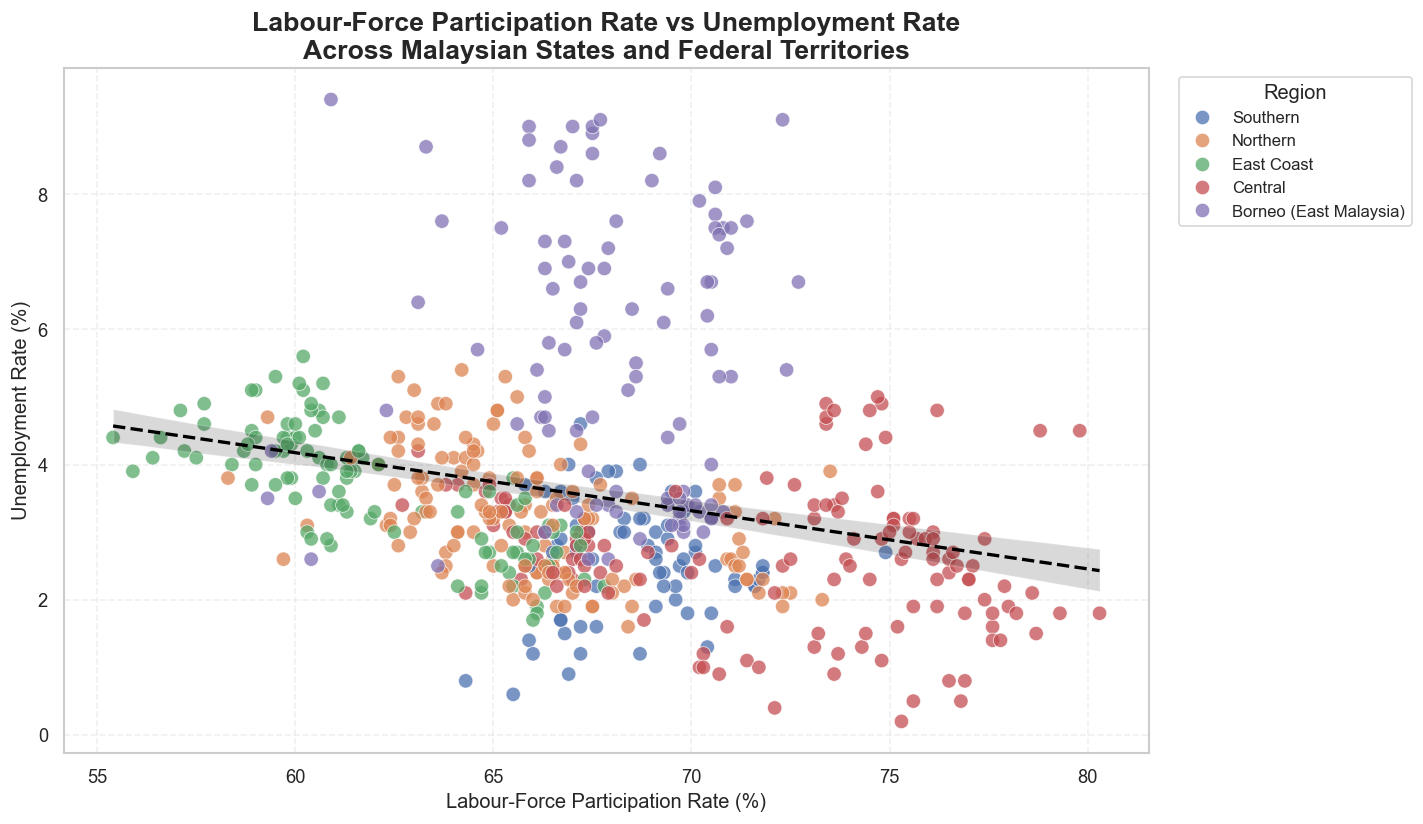

Figure saved successfully: figures\03_participation_vs_unemployment_scatter.png


In [14]:
# FIGURE 3: Labour-force participation rate versus unemployment rate

scatter_df = df_qtr.dropna(
    subset=["p_rate", "u_rate", "region"]
).copy()

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_df,
    x="p_rate",
    y="u_rate",
    hue="region",
    s=75,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5
)

# Add an overall trend line

sns.regplot(
    data=scatter_df,
    x="p_rate",
    y="u_rate",
    scatter=False,
    color="black",
    line_kws={
        "linestyle": "--",
        "linewidth": 2,
        "label": "Overall trend"
    }
)

plt.title(
    "Labour-Force Participation Rate vs Unemployment Rate\n"
    "Across Malaysian States and Federal Territories",
    fontweight="bold"
)

plt.xlabel("Labour-Force Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

save_and_show_figure(
    "03_participation_vs_unemployment_scatter"
)

In [15]:
# Calculate the relationship shown in Figure 3

correlation = scatter_df["p_rate"].corr(
    scatter_df["u_rate"]
)

highest_records = (
    scatter_df[
        ["date", "state", "region", "p_rate", "u_rate"]
    ]
    .sort_values("u_rate", ascending=False)
    .head(5)
    .copy()
)

highest_records["quarter"] = (
    highest_records["date"]
    .dt.to_period("Q")
    .astype(str)
)

print("FIGURE 3 FINDINGS")
print("=" * 60)

print(
    f"Correlation between participation rate and "
    f"unemployment rate: {correlation:.3f}"
)

if correlation >= 0.7:
    relationship = "strong positive"
elif correlation >= 0.3:
    relationship = "moderate positive"
elif correlation > 0:
    relationship = "weak positive"
elif correlation <= -0.7:
    relationship = "strong negative"
elif correlation <= -0.3:
    relationship = "moderate negative"
elif correlation < 0:
    relationship = "weak negative"
else:
    relationship = "no linear"

print(
    f"Interpretation: The variables have a "
    f"{relationship} relationship."
)

print(
    "\nA correlation does not prove that one variable "
    "directly causes the other."
)

print("\nFive highest unemployment observations:")

display(
    highest_records[
        ["quarter", "state", "region", "p_rate", "u_rate"]
    ].rename(
        columns={
            "quarter": "Quarter",
            "state": "State",
            "region": "Region",
            "p_rate": "Participation Rate (%)",
            "u_rate": "Unemployment Rate (%)"
        }
    )
)

FIGURE 3 FINDINGS
Correlation between participation rate and unemployment rate: -0.253
Interpretation: The variables have a weak negative relationship.

A correlation does not prove that one variable directly causes the other.

Five highest unemployment observations:


,Quarter,State,Region,Participation Rate (%),Unemployment Rate (%)
491,2017Q2,W.P. Labuan,Borneo (East Malaysia),60.9,9.4
335,2022Q1,Sabah,Borneo (East Malaysia),67.7,9.1
328,2020Q2,Sabah,Borneo (East Malaysia),72.3,9.1
333,2021Q3,Sabah,Borneo (East Malaysia),65.9,9.0
506,2021Q1,W.P. Labuan,Borneo (East Malaysia),67.0,9.0


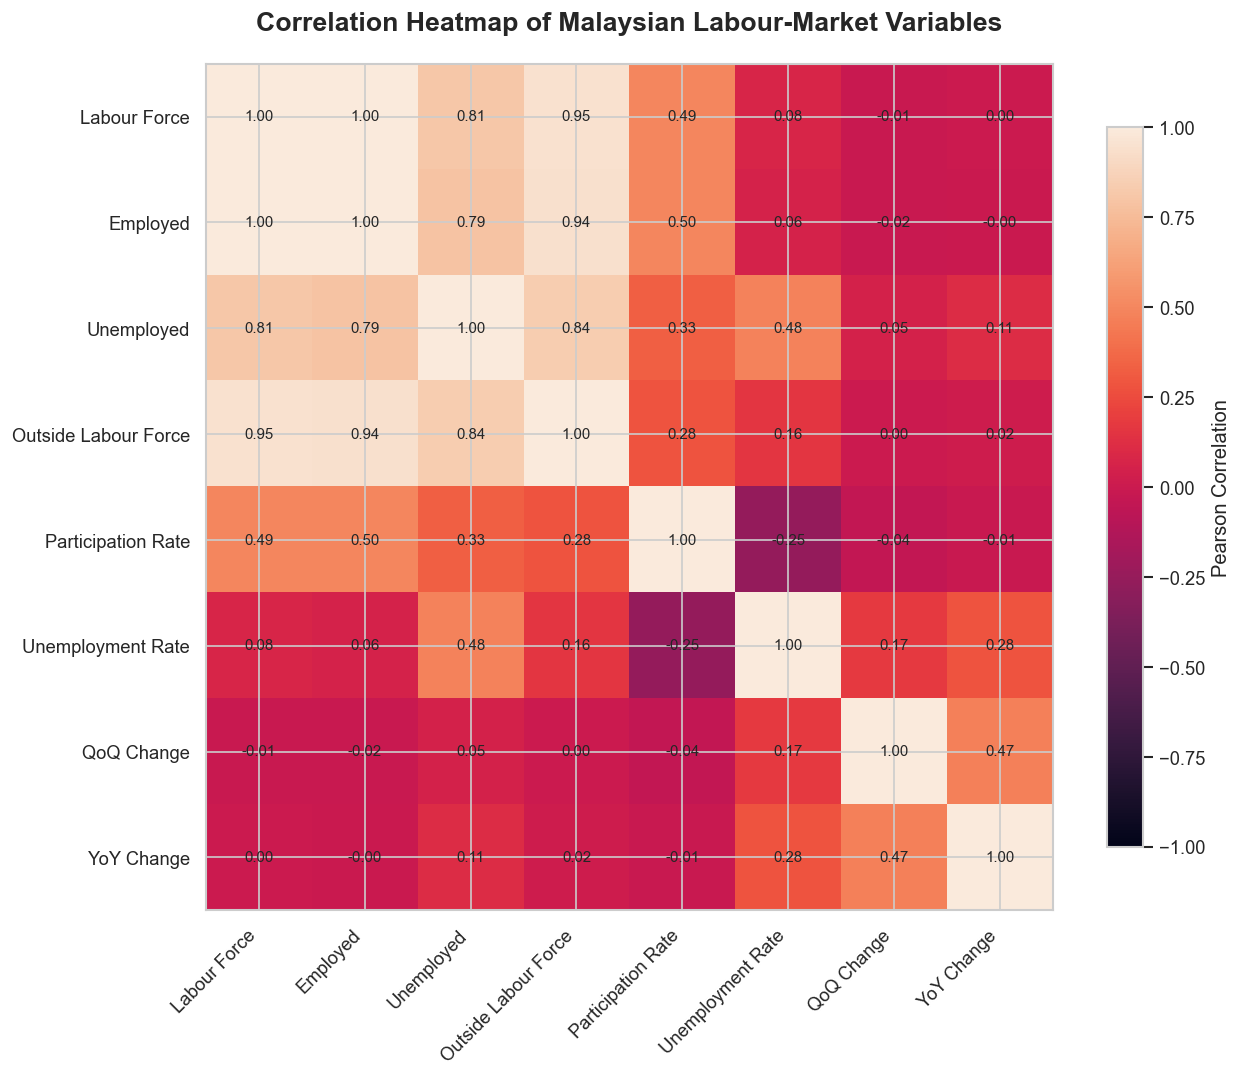

Figure saved successfully: figures\04_labour_market_correlation_heatmap.png


In [16]:
# FIGURE 4: Correlation heatmap for labour-market variables

correlation_columns = [
    "lf",
    "lf_employed",
    "lf_unemployed",
    "lf_outside",
    "p_rate",
    "u_rate",
    "qoq_change_pp",
    "yoy_change_pp"
]

correlation_labels = [
    "Labour Force",
    "Employed",
    "Unemployed",
    "Outside Labour Force",
    "Participation Rate",
    "Unemployment Rate",
    "QoQ Change",
    "YoY Change"
]

correlation_matrix = (
    df_qtr[correlation_columns]
    .corr()
)

fig, ax = plt.subplots(figsize=(11, 9))

heatmap = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

# Add correlation values inside each box

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        value = correlation_matrix.iloc[row, column]

        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_xticks(range(len(correlation_labels)))
ax.set_yticks(range(len(correlation_labels)))

ax.set_xticklabels(
    correlation_labels,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_labels)

ax.set_title(
    "Correlation Heatmap of Malaysian Labour-Market Variables",
    fontweight="bold",
    pad=20
)

color_bar = fig.colorbar(
    heatmap,
    ax=ax,
    shrink=0.85
)

color_bar.set_label("Pearson Correlation")

plt.tight_layout()

save_and_show_figure(
    "04_labour_market_correlation_heatmap"
)

In [17]:
# Identify correlations involving unemployment rate

unemployment_correlations = (
    correlation_matrix["u_rate"]
    .drop("u_rate")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

print("FIGURE 4 FINDINGS")
print("=" * 60)

print("Correlations with unemployment rate:")

for variable, value in unemployment_correlations.items():
    readable_name = {
        "lf": "Labour force",
        "lf_employed": "Employed persons",
        "lf_unemployed": "Unemployed persons",
        "lf_outside": "Outside labour force",
        "p_rate": "Participation rate",
        "qoq_change_pp": "Quarter-over-quarter change",
        "yoy_change_pp": "Year-over-year change"
    }[variable]

    if abs(value) >= 0.70:
        strength = "strong"
    elif abs(value) >= 0.40:
        strength = "moderate"
    elif abs(value) >= 0.20:
        strength = "weak"
    else:
        strength = "very weak"

    direction = "positive" if value > 0 else "negative"

    print(
        f"{readable_name}: {value:.3f} "
        f"({strength} {direction})"
    )

print(
    "\nImportant note: Strong correlations among labour force, "
    "employment and unemployment counts are partly influenced by "
    "state population size. Correlation shows association, not causation."
)

FIGURE 4 FINDINGS
Correlations with unemployment rate:
Unemployed persons: 0.484 (moderate positive)
Year-over-year change: 0.284 (weak positive)
Participation rate: -0.253 (weak negative)
Quarter-over-quarter change: 0.174 (very weak positive)
Outside labour force: 0.160 (very weak positive)
Labour force: 0.076 (very weak positive)
Employed persons: 0.057 (very weak positive)

Important note: Strong correlations among labour force, employment and unemployment counts are partly influenced by state population size. Correlation shows association, not causation.


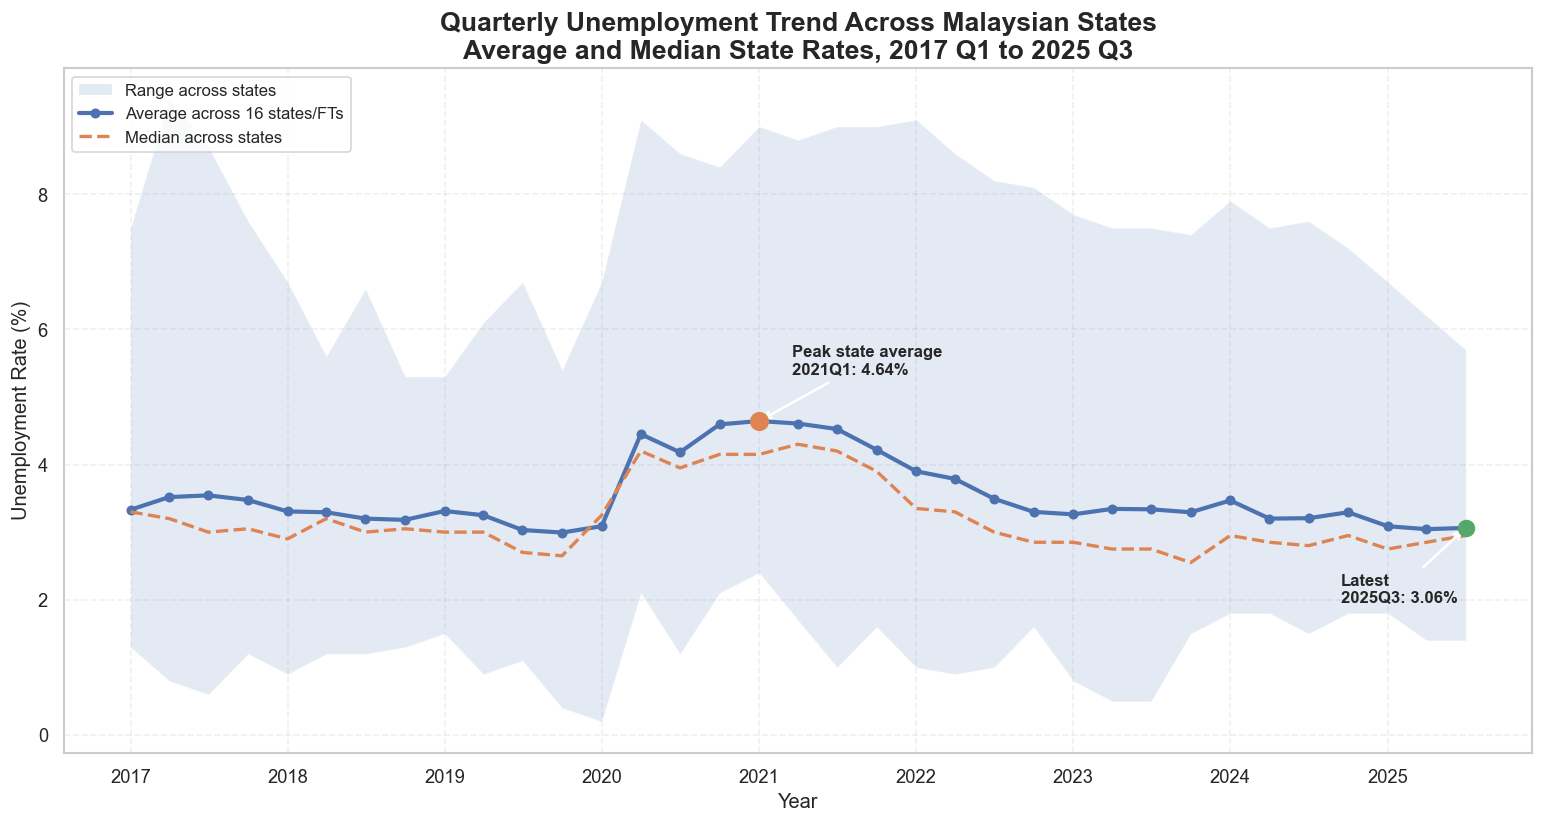

Figure saved successfully: figures\05_quarterly_unemployment_trend.png


In [18]:
# FIGURE 5: Average quarterly unemployment trend across states

import matplotlib.dates as mdates

# Calculate the average, median, highest and lowest state rates per quarter

quarterly_trend = (
    df_qtr.groupby("date", as_index=False)
    .agg(
        average_state_rate=("u_rate", "mean"),
        median_state_rate=("u_rate", "median"),
        highest_state_rate=("u_rate", "max"),
        lowest_state_rate=("u_rate", "min")
    )
    .sort_values("date")
)

# Find the peak quarter and latest quarter

peak_row = quarterly_trend.loc[
    quarterly_trend["average_state_rate"].idxmax()
]

latest_row = quarterly_trend.iloc[-1]

fig, ax = plt.subplots(figsize=(13, 7))

# Show the range between the lowest and highest state rates

ax.fill_between(
    quarterly_trend["date"],
    quarterly_trend["lowest_state_rate"],
    quarterly_trend["highest_state_rate"],
    alpha=0.15,
    label="Range across states"
)

# Average state unemployment rate

ax.plot(
    quarterly_trend["date"],
    quarterly_trend["average_state_rate"],
    marker="o",
    markersize=5,
    linewidth=2.5,
    label="Average across 16 states/FTs"
)

# Median state unemployment rate

ax.plot(
    quarterly_trend["date"],
    quarterly_trend["median_state_rate"],
    linestyle="--",
    linewidth=2,
    label="Median across states"
)

# Highlight the peak quarter

ax.scatter(
    peak_row["date"],
    peak_row["average_state_rate"],
    s=110,
    zorder=5
)

ax.annotate(
    (
        f"Peak state average\n"
        f"{peak_row['date'].to_period('Q')}: "
        f"{peak_row['average_state_rate']:.2f}%"
    ),
    xy=(
        peak_row["date"],
        peak_row["average_state_rate"]
    ),
    xytext=(20, 28),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.5
    },
    fontsize=10,
    fontweight="bold"
)

# Highlight the latest quarter

ax.scatter(
    latest_row["date"],
    latest_row["average_state_rate"],
    s=90,
    zorder=5
)

ax.annotate(
    (
        f"Latest\n"
        f"{latest_row['date'].to_period('Q')}: "
        f"{latest_row['average_state_rate']:.2f}%"
    ),
    xy=(
        latest_row["date"],
        latest_row["average_state_rate"]
    ),
    xytext=(-75, -45),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.5
    },
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Quarterly Unemployment Trend Across Malaysian States\n"
    "Average and Median State Rates, 2017 Q1 to 2025 Q3",
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Unemployment Rate (%)")

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

plt.tight_layout()

save_and_show_figure(
    "05_quarterly_unemployment_trend"
)

In [19]:
# Calculate the important findings for Figure 5

pre_2020_average = quarterly_trend.loc[
    quarterly_trend["date"].dt.year <= 2019,
    "average_state_rate"
].mean()

period_2020_2021_average = quarterly_trend.loc[
    quarterly_trend["date"].dt.year.between(2020, 2021),
    "average_state_rate"
].mean()

recent_average = quarterly_trend.loc[
    quarterly_trend["date"].dt.year >= 2023,
    "average_state_rate"
].mean()

change_from_peak = (
    latest_row["average_state_rate"]
    - peak_row["average_state_rate"]
)

print("FIGURE 5 FINDINGS")
print("=" * 60)

print(
    f"Peak quarter: "
    f"{peak_row['date'].to_period('Q')}"
)

print(
    f"Peak average unemployment rate across states: "
    f"{peak_row['average_state_rate']:.2f}%"
)

print(
    f"Latest quarter: "
    f"{latest_row['date'].to_period('Q')}"
)

print(
    f"Latest average unemployment rate across states: "
    f"{latest_row['average_state_rate']:.2f}%"
)

print(
    f"\nAverage during 2017–2019: "
    f"{pre_2020_average:.2f}%"
)

print(
    f"Average during 2020–2021: "
    f"{period_2020_2021_average:.2f}%"
)

print(
    f"Average from 2023 onwards: "
    f"{recent_average:.2f}%"
)

print(
    f"\nChange from the peak quarter to the latest quarter: "
    f"{change_from_peak:.2f} percentage points"
)

if change_from_peak < 0:
    print(
        "\nInterpretation: The average unemployment rate across "
        "states declined after reaching its highest point. However, "
        "the shaded range shows that unemployment conditions still "
        "differ considerably between states."
    )
else:
    print(
        "\nInterpretation: The latest state-average unemployment "
        "rate remains above the earlier peak."
    )

print(
    "\nNote: These values are unweighted averages across the "
    "16 states and federal territories, not the official national rate."
)

FIGURE 5 FINDINGS
Peak quarter: 2021Q1
Peak average unemployment rate across states: 4.64%
Latest quarter: 2025Q3
Latest average unemployment rate across states: 3.06%

Average during 2017–2019: 3.29%
Average during 2020–2021: 4.29%
Average from 2023 onwards: 3.24%

Change from the peak quarter to the latest quarter: -1.58 percentage points

Interpretation: The average unemployment rate across states declined after reaching its highest point. However, the shaded range shows that unemployment conditions still differ considerably between states.

Note: These values are unweighted averages across the 16 states and federal territories, not the official national rate.


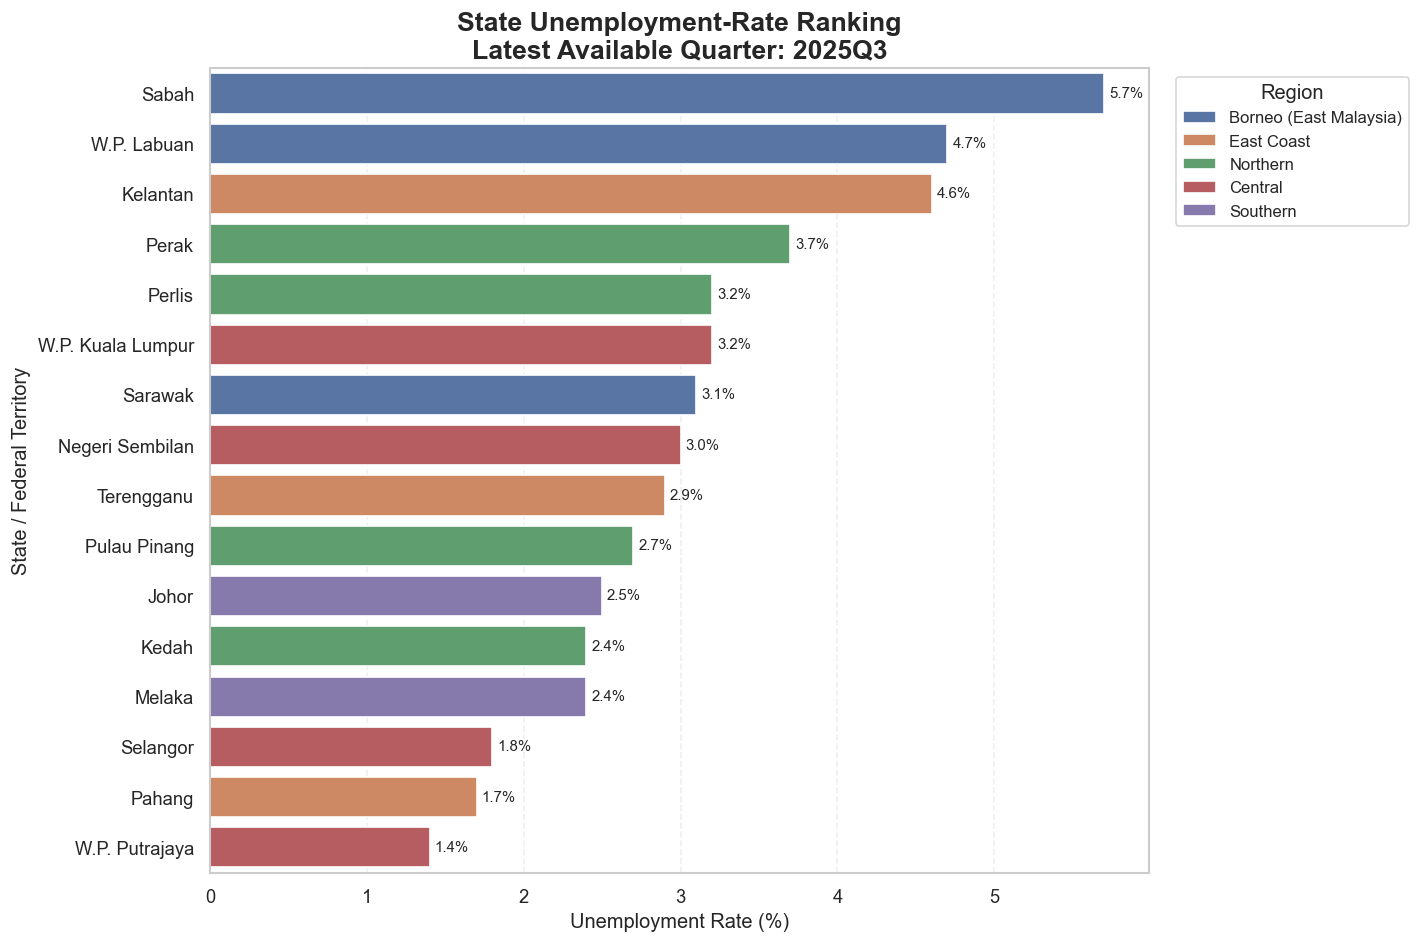

Figure saved successfully: figures\06_latest_quarter_state_ranking.png


In [20]:
# FIGURE 6: Unemployment-rate ranking for the latest available quarter

latest_date = df_qtr["date"].max()

latest_state_data = (
    df_qtr[df_qtr["date"] == latest_date]
    .sort_values("u_rate", ascending=False)
    .copy()
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=latest_state_data,
    x="u_rate",
    y="state",
    hue="region",
    dodge=False
)

# Add unemployment-rate labels to each bar

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.title(
    "State Unemployment-Rate Ranking\n"
    f"Latest Available Quarter: {latest_date.to_period('Q')}",
    fontweight="bold"
)

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State / Federal Territory")

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

save_and_show_figure(
    "06_latest_quarter_state_ranking"
)

In [21]:
# Calculate findings for Figure 6

highest_latest = latest_state_data.iloc[0]
lowest_latest = latest_state_data.iloc[-1]

latest_average = latest_state_data["u_rate"].mean()
latest_median = latest_state_data["u_rate"].median()

above_average_states = latest_state_data[
    latest_state_data["u_rate"] > latest_average
]

print("FIGURE 6 FINDINGS")
print("=" * 60)

print(
    f"Latest available quarter: "
    f"{latest_date.to_period('Q')}"
)

print(
    f"Highest unemployment rate: "
    f"{highest_latest['state']} "
    f"({highest_latest['u_rate']:.1f}%)"
)

print(
    f"Lowest unemployment rate: "
    f"{lowest_latest['state']} "
    f"({lowest_latest['u_rate']:.1f}%)"
)

print(
    f"Average across the 16 states/FTs: "
    f"{latest_average:.2f}%"
)

print(
    f"Median across the 16 states/FTs: "
    f"{latest_median:.2f}%"
)

print(
    f"Number of states/FTs above the latest-quarter average: "
    f"{len(above_average_states)}"
)

print("\nStates/FTs above the latest-quarter average:")

display(
    above_average_states[
        ["state", "region", "u_rate", "state_rank_qtr"]
    ].rename(
        columns={
            "state": "State",
            "region": "Region",
            "u_rate": "Unemployment Rate (%)",
            "state_rank_qtr": "Quarterly Rank"
        }
    )
)

print(
    "\nNote: The ranking compares states and federal territories "
    "within the same quarter. It is not a national unemployment ranking."
)

FIGURE 6 FINDINGS
Latest available quarter: 2025Q3
Highest unemployment rate: Sabah (5.7%)
Lowest unemployment rate: W.P. Putrajaya (1.4%)
Average across the 16 states/FTs: 3.06%
Median across the 16 states/FTs: 2.95%
Number of states/FTs above the latest-quarter average: 7

States/FTs above the latest-quarter average:


,State,Region,Unemployment Rate (%),Quarterly Rank
349,Sabah,Borneo (East Malaysia),5.7,16
524,W.P. Labuan,Borneo (East Malaysia),4.7,15
104,Kelantan,East Coast,4.6,14
244,Perak,Northern,3.7,13
279,Perlis,Northern,3.2,11
489,W.P. Kuala Lumpur,Central,3.2,11
384,Sarawak,Borneo (East Malaysia),3.1,10



Note: The ranking compares states and federal territories within the same quarter. It is not a national unemployment ranking.


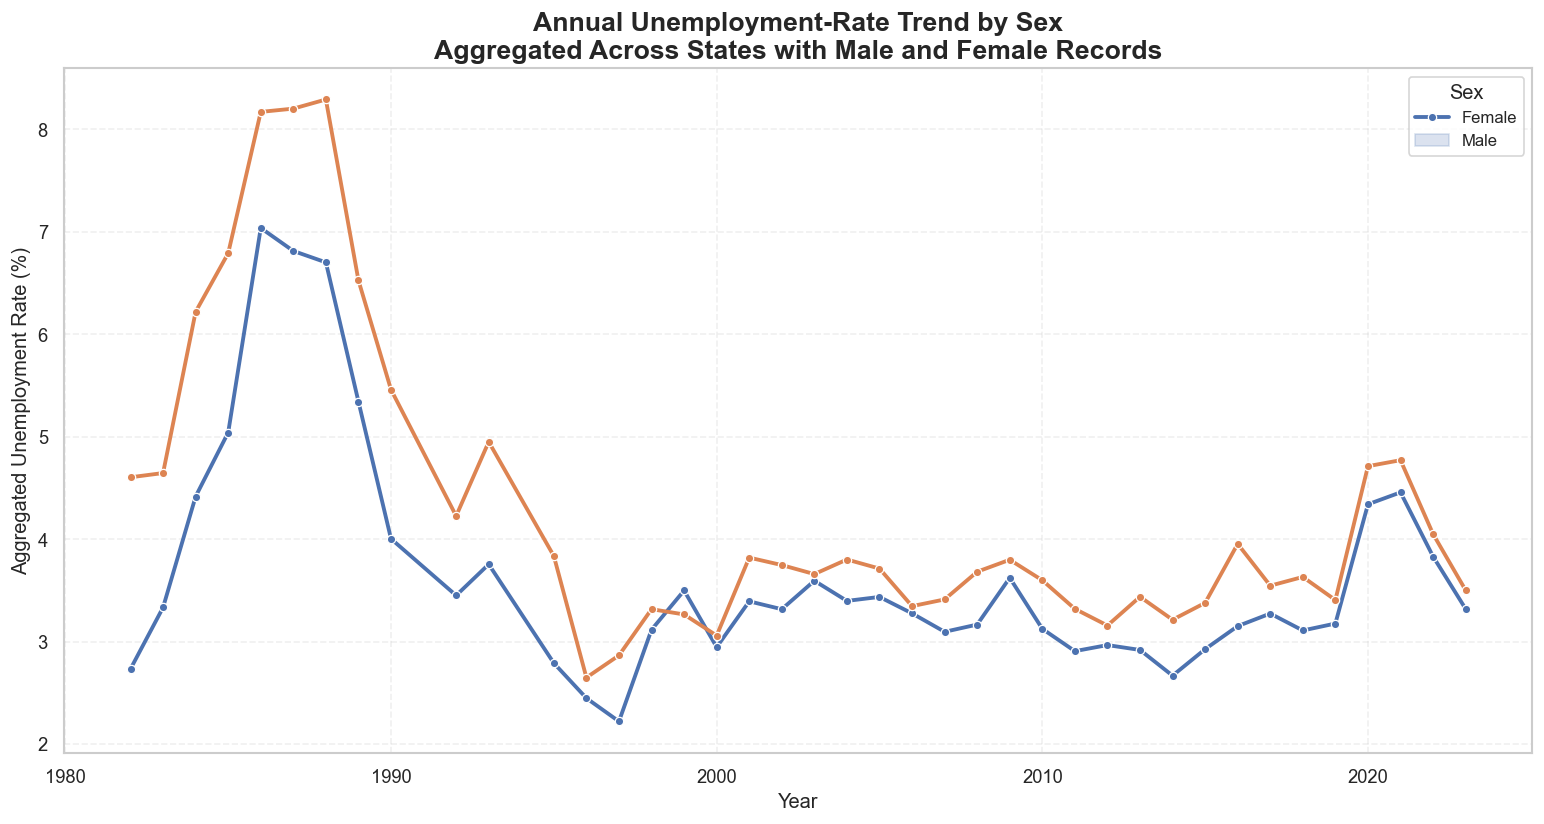

Figure saved successfully: figures\07_annual_unemployment_trend_by_sex.png


In [22]:
# FIGURE 7: Annual male and female unemployment-rate trend

# Use only male and female records.
# Negeri Sembilan is automatically excluded because it only has "both".

gender_records = df_gender[
    df_gender["sex"].isin(["male", "female"])
].copy()

# Combine state counts to calculate an overall rate for each year and sex

gender_trend = (
    gender_records
    .groupby(["year", "sex"], as_index=False)
    .agg(
        labour_force=("lf", "sum"),
        unemployed=("lf_unemployed", "sum")
    )
)

gender_trend["aggregated_u_rate"] = (
    gender_trend["unemployed"]
    / gender_trend["labour_force"]
    * 100
)

# Add missing years so genuine source-data gaps appear as breaks

all_years = range(
    int(df_gender["year"].min()),
    int(df_gender["year"].max()) + 1
)

full_index = pd.MultiIndex.from_product(
    [all_years, ["male", "female"]],
    names=["year", "sex"]
)

gender_trend = (
    gender_trend
    .set_index(["year", "sex"])
    .reindex(full_index)
    .reset_index()
)

# Find the latest year containing both male and female data

gender_pivot = gender_trend.pivot(
    index="year",
    columns="sex",
    values="aggregated_u_rate"
)

latest_gender_year = gender_pivot.dropna().index.max()

plt.figure(figsize=(13, 7))

ax = sns.lineplot(
    data=gender_trend,
    x="year",
    y="aggregated_u_rate",
    hue="sex",
    marker="o",
    linewidth=2.3,
    markersize=5
)

plt.title(
    "Annual Unemployment-Rate Trend by Sex\n"
    "Aggregated Across States with Male and Female Records",
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Aggregated Unemployment Rate (%)")

plt.legend(
    title="Sex",
    labels=["Female", "Male"]
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

save_and_show_figure(
    "07_annual_unemployment_trend_by_sex"
)

In [23]:
# Calculate the key findings for Figure 7

latest_female_rate = gender_pivot.loc[
    latest_gender_year,
    "female"
]

latest_male_rate = gender_pivot.loc[
    latest_gender_year,
    "male"
]

gender_gap = latest_female_rate - latest_male_rate

female_peak_year = gender_pivot["female"].idxmax()
male_peak_year = gender_pivot["male"].idxmax()

female_peak_rate = gender_pivot["female"].max()
male_peak_rate = gender_pivot["male"].max()

print("FIGURE 7 FINDINGS")
print("=" * 60)

print(f"Latest complete year: {latest_gender_year}")

print(
    f"Female unemployment rate: "
    f"{latest_female_rate:.2f}%"
)

print(
    f"Male unemployment rate: "
    f"{latest_male_rate:.2f}%"
)

print(
    f"Female minus male gap: "
    f"{gender_gap:.2f} percentage points"
)

print(
    f"\nFemale peak: {female_peak_year} "
    f"({female_peak_rate:.2f}%)"
)

print(
    f"Male peak: {male_peak_year} "
    f"({male_peak_rate:.2f}%)"
)

if gender_gap > 0:
    print(
        "\nInterpretation: The aggregated female unemployment "
        "rate was higher than the male rate in the latest year."
    )
elif gender_gap < 0:
    print(
        "\nInterpretation: The aggregated male unemployment "
        "rate was higher than the female rate in the latest year."
    )
else:
    print(
        "\nInterpretation: Male and female unemployment rates "
        "were equal in the latest year."
    )

print(
    "\nImportant note: Negeri Sembilan is excluded because "
    "the supporting dataset does not provide separate male and "
    "female records for that state."
)

print(
    "The blank sections around 1991 and 1994 represent genuine "
    "gaps in the source data, not coding errors."
)

FIGURE 7 FINDINGS
Latest complete year: 2023
Female unemployment rate: 3.50%
Male unemployment rate: 3.32%
Female minus male gap: 0.18 percentage points

Female peak: 1988 (8.29%)
Male peak: 1986 (7.04%)

Interpretation: The aggregated female unemployment rate was higher than the male rate in the latest year.

Important note: Negeri Sembilan is excluded because the supporting dataset does not provide separate male and female records for that state.
The blank sections around 1991 and 1994 represent genuine gaps in the source data, not coding errors.


In [24]:
# Prepare the data needed for the interactive dashboard

dashboard_qtr = df_qtr.copy()

dashboard_qtr["quarter_label"] = (
    dashboard_qtr["date"]
    .dt.to_period("Q")
    .astype(str)
)

latest_date = dashboard_qtr["date"].max()

latest_dashboard_data = (
    dashboard_qtr[
        dashboard_qtr["date"] == latest_date
    ]
    .sort_values("u_rate", ascending=False)
    .copy()
)

quarterly_dashboard_trend = (
    dashboard_qtr
    .groupby("date", as_index=False)
    .agg(
        average_state_rate=("u_rate", "mean"),
        median_state_rate=("u_rate", "median")
    )
)

print("Dashboard data prepared successfully.")
print("Latest quarter:", latest_date.to_period("Q"))
print("States/FTs included:", dashboard_qtr["state"].nunique())

Dashboard data prepared successfully.
Latest quarter: 2025Q3
States/FTs included: 16


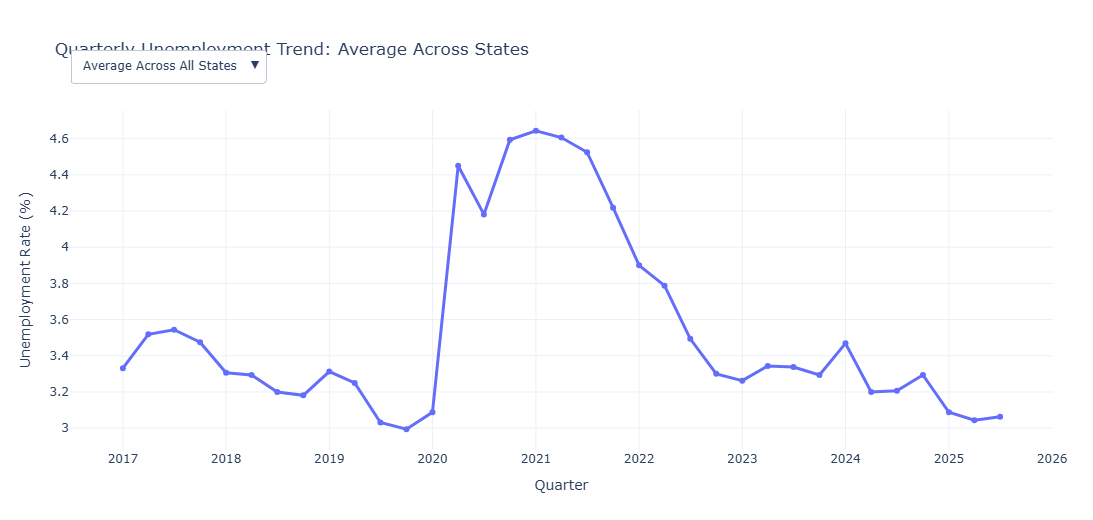

In [25]:
# INTERACTIVE CHART 1:
# Quarterly unemployment trend with a state dropdown

states = sorted(
    dashboard_qtr["state"].dropna().unique()
)

trend_figure = go.Figure()

# First trace: average across all states

trend_figure.add_trace(
    go.Scatter(
        x=quarterly_dashboard_trend["date"],
        y=quarterly_dashboard_trend["average_state_rate"],
        mode="lines+markers",
        name="Average across states",
        line=dict(width=3),
        marker=dict(size=6),
        hovertemplate=(
            "<b>%{x|%Y Q%q}</b><br>"
            "Average unemployment rate: %{y:.2f}%"
            "<extra></extra>"
        ),
        visible=True
    )
)

# Add one trace for every state

for state in states:
    state_data = (
        dashboard_qtr[
            dashboard_qtr["state"] == state
        ]
        .sort_values("date")
    )

    trend_figure.add_trace(
        go.Scatter(
            x=state_data["date"],
            y=state_data["u_rate"],
            mode="lines+markers",
            name=state,
            line=dict(width=3),
            marker=dict(size=6),
            customdata=state_data[
                ["qoq_change_pp", "yoy_change_pp"]
            ].to_numpy(),
            hovertemplate=(
                f"<b>{state}</b><br>"
                "Quarter: %{x|%Y Q%q}<br>"
                "Unemployment rate: %{y:.2f}%<br>"
                "QoQ change: %{customdata[0]:.2f} pp<br>"
                "YoY change: %{customdata[1]:.2f} pp"
                "<extra></extra>"
            ),
            visible=False
        )
    )

# Create dropdown buttons

dropdown_buttons = []

dropdown_buttons.append(
    dict(
        label="Average Across All States",
        method="update",
        args=[
            {
                "visible":
                [True] + [False] * len(states)
            },
            {
                "title":
                "Quarterly Unemployment Trend: Average Across States"
            }
        ]
    )
)

for index, state in enumerate(states):
    visibility = [False] * (len(states) + 1)
    visibility[index + 1] = True

    dropdown_buttons.append(
        dict(
            label=state,
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title":
                    f"Quarterly Unemployment Trend: {state}"
                }
            ]
        )
    )

trend_figure.update_layout(
    title="Quarterly Unemployment Trend: Average Across States",
    xaxis_title="Quarter",
    yaxis_title="Unemployment Rate (%)",
    template="plotly_white",
    height=520,
    margin=dict(
        l=70,
        r=40,
        t=110,
        b=70
    ),
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0,
            xanchor="left",
            y=1.18,
            yanchor="top"
        )
    ],
    hovermode="x unified"
)

trend_figure.show()

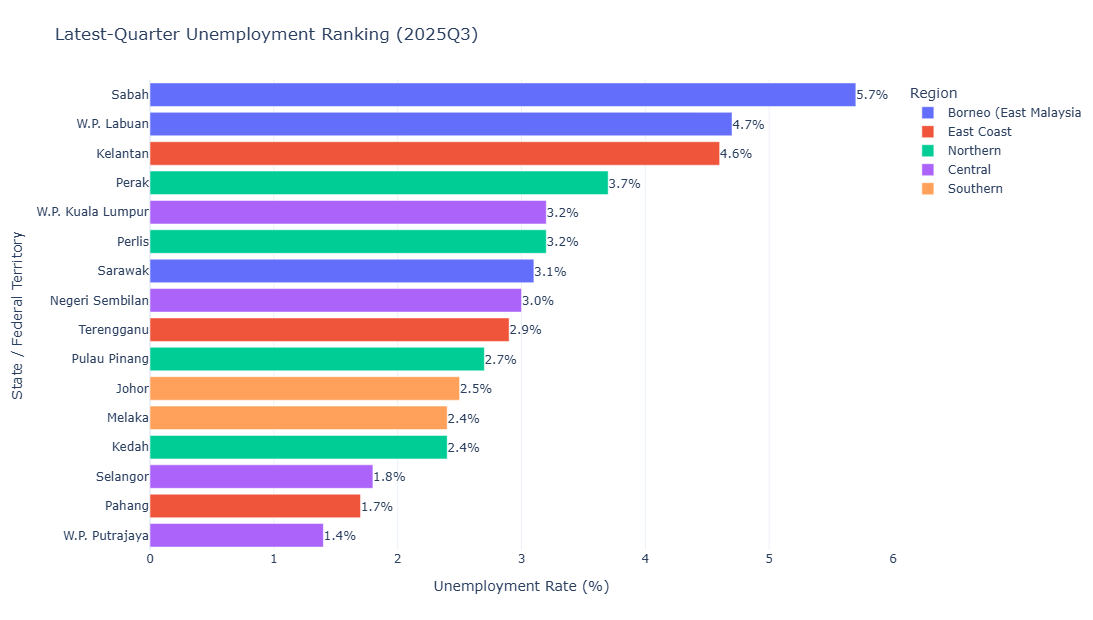

In [26]:
# INTERACTIVE CHART 2:
# Latest-quarter state unemployment ranking

ranking_figure = px.bar(
    latest_dashboard_data,
    x="u_rate",
    y="state",
    color="region",
    orientation="h",
    text="u_rate",
    title=(
        "Latest-Quarter Unemployment Ranking "
        f"({latest_date.to_period('Q')})"
    ),
    labels={
        "u_rate": "Unemployment Rate (%)",
        "state": "State / Federal Territory",
        "region": "Region"
    },
    hover_data={
        "u_rate": ":.1f",
        "p_rate": ":.1f",
        "lf_unemployed": ":.1f",
        "state_rank_qtr": True,
        "region": True
    }
)

ranking_figure.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

ranking_figure.update_layout(
    template="plotly_white",
    height=620,
    yaxis=dict(
        categoryorder="total ascending"
    ),
    margin=dict(
        l=150,
        r=60,
        t=80,
        b=70
    ),
    legend_title_text="Region"
)

ranking_figure.show()

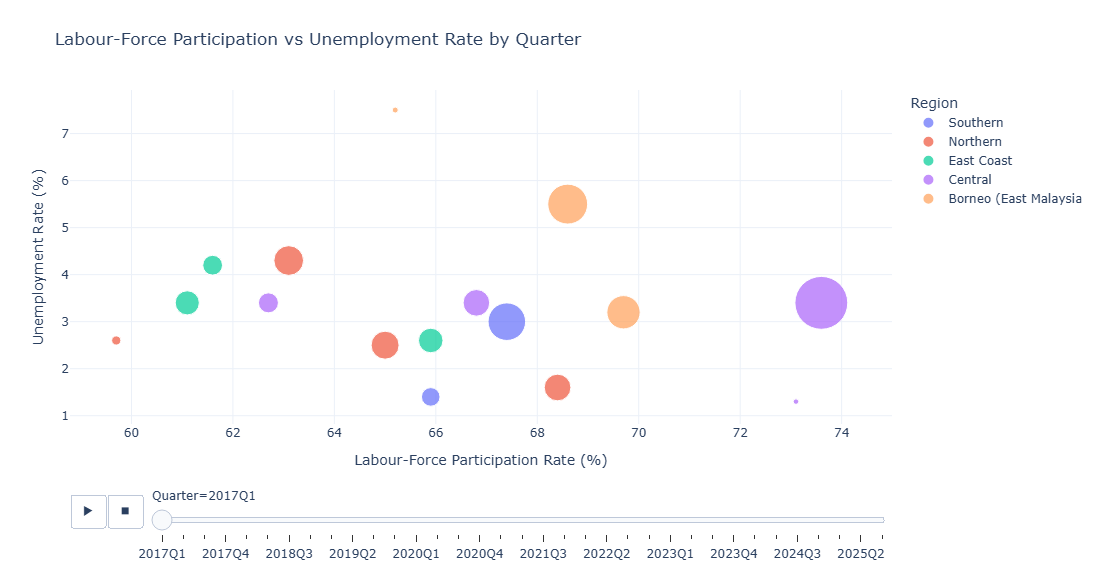

In [27]:
# INTERACTIVE CHART 3:
# Participation rate versus unemployment rate

scatter_figure = px.scatter(
    dashboard_qtr,
    x="p_rate",
    y="u_rate",
    color="region",
    size="lf",
    hover_name="state",
    animation_frame="quarter_label",
    animation_group="state",
    title=(
        "Labour-Force Participation vs Unemployment Rate "
        "by Quarter"
    ),
    labels={
        "p_rate": "Labour-Force Participation Rate (%)",
        "u_rate": "Unemployment Rate (%)",
        "region": "Region",
        "lf": "Labour Force ('000 persons)",
        "quarter_label": "Quarter"
    },
    hover_data={
        "lf": ":.1f",
        "lf_employed": ":.1f",
        "lf_unemployed": ":.1f",
        "p_rate": ":.1f",
        "u_rate": ":.1f"
    },
    size_max=42
)

scatter_figure.update_layout(
    template="plotly_white",
    height=580,
    margin=dict(
        l=70,
        r=40,
        t=90,
        b=70
    ),
    legend_title_text="Region"
)

scatter_figure.show()

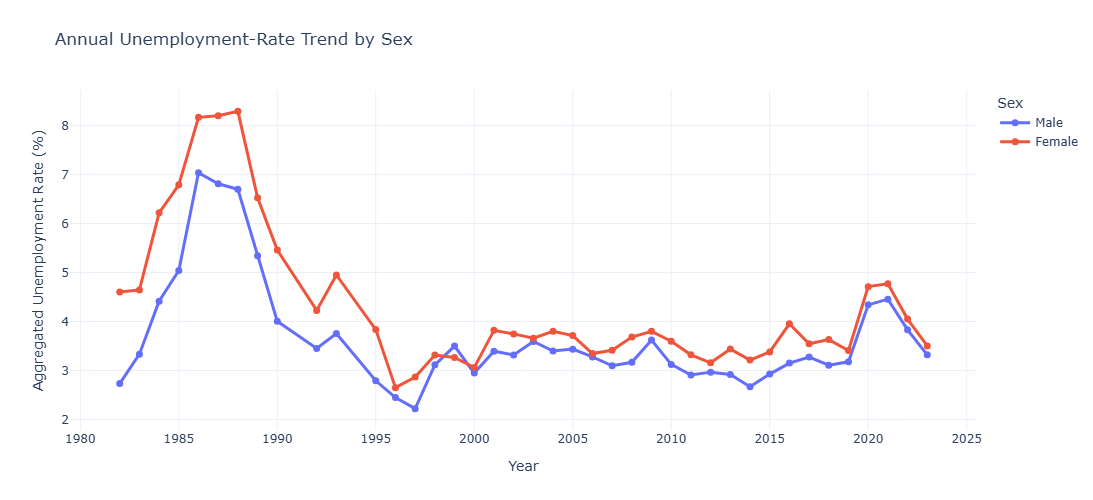

In [28]:
# INTERACTIVE CHART 4:
# Annual unemployment trend by sex

interactive_gender_data = (
    gender_trend
    .dropna(subset=["aggregated_u_rate"])
    .copy()
)

interactive_gender_data["Sex"] = (
    interactive_gender_data["sex"]
    .str.title()
)

gender_figure = px.line(
    interactive_gender_data,
    x="year",
    y="aggregated_u_rate",
    color="Sex",
    markers=True,
    title="Annual Unemployment-Rate Trend by Sex",
    labels={
        "year": "Year",
        "aggregated_u_rate":
        "Aggregated Unemployment Rate (%)"
    }
)

gender_figure.update_traces(
    line=dict(width=3),
    marker=dict(size=7),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Year: %{x}<br>"
        "Unemployment rate: %{y:.2f}%"
        "<extra></extra>"
    )
)

gender_figure.update_layout(
    template="plotly_white",
    height=500,
    margin=dict(
        l=70,
        r=40,
        t=90,
        b=70
    )
)

gender_figure.show()

In [29]:
# Calculate the key values displayed at the top of the dashboard

latest_quarter_label = str(latest_date.to_period("Q"))

latest_average_rate = latest_dashboard_data["u_rate"].mean()

highest_latest_row = latest_dashboard_data.loc[
    latest_dashboard_data["u_rate"].idxmax()
]

lowest_latest_row = latest_dashboard_data.loc[
    latest_dashboard_data["u_rate"].idxmin()
]

peak_dashboard_row = quarterly_dashboard_trend.loc[
    quarterly_dashboard_trend["average_state_rate"].idxmax()
]

dashboard_correlation = dashboard_qtr["p_rate"].corr(
    dashboard_qtr["u_rate"]
)

# Latest complete gender year

latest_complete_gender = (
    gender_pivot.dropna(subset=["female", "male"]).index.max()
)

latest_dashboard_female_rate = gender_pivot.loc[
    latest_complete_gender,
    "female"
]

latest_dashboard_male_rate = gender_pivot.loc[
    latest_complete_gender,
    "male"
]

print("DASHBOARD SUMMARY")
print("=" * 60)

print("Latest quarter:", latest_quarter_label)
print(f"Average state unemployment rate: {latest_average_rate:.2f}%")

print(
    f"Highest state/FT: {highest_latest_row['state']} "
    f"({highest_latest_row['u_rate']:.1f}%)"
)

print(
    f"Lowest state/FT: {lowest_latest_row['state']} "
    f"({lowest_latest_row['u_rate']:.1f}%)"
)

print(
    f"Peak state-average quarter: "
    f"{peak_dashboard_row['date'].to_period('Q')} "
    f"({peak_dashboard_row['average_state_rate']:.2f}%)"
)

print(
    f"Participation-unemployment correlation: "
    f"{dashboard_correlation:.3f}"
)

print(
    f"Latest complete gender year: "
    f"{latest_complete_gender}"
)

DASHBOARD SUMMARY
Latest quarter: 2025Q3
Average state unemployment rate: 3.06%
Highest state/FT: Sabah (5.7%)
Lowest state/FT: W.P. Putrajaya (1.4%)
Peak state-average quarter: 2021Q1 (4.64%)
Participation-unemployment correlation: -0.253
Latest complete gender year: 2023


In [30]:
# Export all four interactive charts into one standalone HTML dashboard

plotly_config = {
    "responsive": True,
    "displaylogo": False,
    "scrollZoom": False,
    "modeBarButtonsToRemove": [
        "lasso2d",
        "select2d"
    ]
}

# Include Plotly JavaScript only once.
# Using "inline" makes the dashboard work without an internet connection.

trend_html = pio.to_html(
    trend_figure,
    full_html=False,
    include_plotlyjs="inline",
    config=plotly_config
)

ranking_html = pio.to_html(
    ranking_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config
)

scatter_html = pio.to_html(
    scatter_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config
)

gender_html = pio.to_html(
    gender_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config
)

dashboard_path = PROJECT_DIR / "tdw_unemployment_dashboard.html"

dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">

    <meta
        name="viewport"
        content="width=device-width, initial-scale=1.0"
    >

    <title>
        Malaysia Unemployment Dashboard
    </title>

    <style>
        * {{
            box-sizing: border-box;
        }}

        body {{
            margin: 0;
            background: #f4f7fb;
            color: #172033;
            font-family:
                Arial,
                Helvetica,
                sans-serif;
        }}

        .header {{
            padding: 38px 24px;
            color: white;
            text-align: center;
            background:
                linear-gradient(
                    135deg,
                    #102a43,
                    #1f6f8b
                );
        }}

        .header h1 {{
            margin: 0;
            font-size: 34px;
        }}

        .header p {{
            max-width: 850px;
            margin: 12px auto 0;
            line-height: 1.6;
            opacity: 0.92;
        }}

        .container {{
            width: min(1450px, 94%);
            margin: 28px auto 50px;
        }}

        .cards {{
            display: grid;
            grid-template-columns:
                repeat(
                    auto-fit,
                    minmax(210px, 1fr)
                );
            gap: 18px;
            margin-bottom: 26px;
        }}

        .card {{
            background: white;
            padding: 22px;
            border-radius: 14px;
            box-shadow:
                0 4px 18px
                rgba(16, 42, 67, 0.08);
            border-top: 5px solid #1f77b4;
        }}

        .card-title {{
            margin-bottom: 9px;
            color: #62748a;
            font-size: 13px;
            font-weight: bold;
            text-transform: uppercase;
            letter-spacing: 0.6px;
        }}

        .card-value {{
            color: #102a43;
            font-size: 26px;
            font-weight: bold;
        }}

        .card-note {{
            margin-top: 7px;
            color: #708090;
            font-size: 13px;
            line-height: 1.4;
        }}

        .section {{
            margin-bottom: 25px;
            padding: 22px;
            background: white;
            border-radius: 14px;
            box-shadow:
                0 4px 18px
                rgba(16, 42, 67, 0.08);
        }}

        .section h2 {{
            margin: 0 0 7px;
            color: #102a43;
            font-size: 22px;
        }}

        .section-description {{
            margin: 0 0 12px;
            color: #62748a;
            line-height: 1.55;
        }}

        .two-column {{
            display: grid;
            grid-template-columns:
                repeat(
                    auto-fit,
                    minmax(500px, 1fr)
                );
            gap: 25px;
        }}

        .insight-box {{
            margin-bottom: 25px;
            padding: 23px 26px;
            color: #17324d;
            background: #eaf5fa;
            border-left: 6px solid #1f6f8b;
            border-radius: 10px;
            line-height: 1.65;
        }}

        .data-note {{
            padding: 21px 24px;
            background: #fff7df;
            border-left: 6px solid #d89c13;
            border-radius: 10px;
            color: #594513;
            line-height: 1.6;
        }}

        footer {{
            padding: 24px;
            text-align: center;
            color: #708090;
            font-size: 13px;
        }}

        @media (max-width: 650px) {{
            .header h1 {{
                font-size: 27px;
            }}

            .two-column {{
                grid-template-columns: 1fr;
            }}

            .section {{
                padding: 12px;
            }}
        }}
    </style>
</head>

<body>

    <header class="header">

        <h1>
            Unemployment Rate in Malaysia
        </h1>

        <p>
            An interactive visual story of quarterly unemployment
            patterns across Malaysian states and federal territories,
            supported by a separate annual gender analysis.
        </p>

    </header>

    <main class="container">

        <div class="cards">

            <div class="card">
                <div class="card-title">
                    Latest Quarter
                </div>

                <div class="card-value">
                    {latest_quarter_label}
                </div>

                <div class="card-note">
                    Most recent quarterly record available
                </div>
            </div>

            <div class="card">
                <div class="card-title">
                    Average State Rate
                </div>

                <div class="card-value">
                    {latest_average_rate:.2f}%
                </div>

                <div class="card-note">
                    Unweighted average across 16 states and FTs
                </div>
            </div>

            <div class="card">
                <div class="card-title">
                    Highest Rate
                </div>

                <div class="card-value">
                    {highest_latest_row['u_rate']:.1f}%
                </div>

                <div class="card-note">
                    {highest_latest_row['state']}
                </div>
            </div>

            <div class="card">
                <div class="card-title">
                    Lowest Rate
                </div>

                <div class="card-value">
                    {lowest_latest_row['u_rate']:.1f}%
                </div>

                <div class="card-note">
                    {lowest_latest_row['state']}
                </div>
            </div>

            <div class="card">
                <div class="card-title">
                    Participation Correlation
                </div>

                <div class="card-value">
                    {dashboard_correlation:.2f}
                </div>

                <div class="card-note">
                    Correlation with unemployment rate
                </div>
            </div>

        </div>

        <div class="insight-box">

            <strong>Latest snapshot:</strong>
            During {latest_quarter_label},
            {highest_latest_row['state']} recorded the highest
            unemployment rate at
            {highest_latest_row['u_rate']:.1f}%,
            while {lowest_latest_row['state']} recorded the lowest
            rate at {lowest_latest_row['u_rate']:.1f}%.
            The average across the 16 states and federal territories
            was {latest_average_rate:.2f}%.

        </div>

        <section class="section">

            <h2>
                1. Quarterly Unemployment Trend
            </h2>

            <p class="section-description">
                Select the overall state average or an individual
                state from the dropdown. Hover over any point to see
                the unemployment rate and quarterly changes.
            </p>

            {trend_html}

        </section>

        <section class="section">

            <h2>
                2. Latest-Quarter State Ranking
            </h2>

            <p class="section-description">
                This chart compares unemployment rates across all
                states and federal territories in the latest
                available quarter. Hover over a bar for additional
                labour-market information.
            </p>

            {ranking_html}

        </section>

        <section class="section">

            <h2>
                3. Participation and Unemployment
            </h2>

            <p class="section-description">
                Press Play or move the quarter slider to observe how
                the relationship changes over time. Bubble size
                represents the total labour force.
            </p>

            {scatter_html}

        </section>

        <section class="section">

            <h2>
                4. Supporting Gender Analysis
            </h2>

            <p class="section-description">
                This annual analysis compares aggregated male and
                female unemployment rates using only states that
                provide separate male and female records.
            </p>

            {gender_html}

        </section>

        <div class="data-note">

            <strong>Important data notes:</strong>

            The quarterly state average is not Malaysia's official
            national unemployment rate because every state receives
            equal weight. The gender dataset is annual and therefore
            is analysed separately rather than merged with the
            quarterly dataset. Negeri Sembilan is excluded from the
            male-female comparison because separate records are not
            available. Historical gaps in 1991 and 1994 originate
            from the source dataset.

        </div>

    </main>

    <footer>
        TDW Project · UI/UX Specialist and Visual Storyteller
    </footer>

</body>

</html>
"""

dashboard_path.write_text(
    dashboard_html,
    encoding="utf-8"
)

print("Dashboard created successfully.")
print("Saved to:", dashboard_path)

Dashboard created successfully.
Saved to: tdw_unemployment_dashboard.html


In [31]:
# Verify the completed dashboard file

if dashboard_path.exists():

    dashboard_size_mb = (
        dashboard_path.stat().st_size
        / (1024 * 1024)
    )

    print("DASHBOARD VERIFICATION SUCCESSFUL")
    print("=" * 60)

    print("File name:", dashboard_path.name)
    print("Location:", dashboard_path.parent)

    print(
        f"File size: {dashboard_size_mb:.2f} MB"
    )

    print("\nThe dashboard is ready to open in a web browser.")

else:
    raise FileNotFoundError(
        "The dashboard HTML file was not created."
    )

DASHBOARD VERIFICATION SUCCESSFUL
File name: tdw_unemployment_dashboard.html
Location: .
File size: 4.92 MB

The dashboard is ready to open in a web browser.


In [32]:
# CELL 30
# Prepare a restrained green-blue visual theme
# with both light and dark dashboard modes.

import json

ACCENT_COLORS = {
    "navy": "#17363D",
    "blue": "#397A9B",
    "teal": "#2F817A",
    "green": "#57927C",
    "soft_blue": "#6C94A8",
    "soft_teal": "#78A89C"
}

REGION_COLORS = {
    "Northern": "#397A9B",
    "Central": "#2F817A",
    "Southern": "#57927C",
    "East Coast": "#6C94A8",
    "Borneo (East Malaysia)": "#78A89C"
}

LIGHT_THEME = {
    "page_background": "#F3F6F5",
    "card_background": "#FFFFFF",
    "plot_background": "#FFFFFF",
    "text": "#1A3036",
    "muted_text": "#65777B",
    "grid": "#E3EAE8",
    "border": "#D4E0DD",
    "accent": "#2F817A"
}

DARK_THEME = {
    "page_background": "#101B1F",
    "card_background": "#18272C",
    "plot_background": "#18272C",
    "text": "#EDF4F2",
    "muted_text": "#A9BCB8",
    "grid": "#2D4146",
    "border": "#344B50",
    "accent": "#66B7A7"
}

THEME_SWITCH_CONFIG = {
    "light": LIGHT_THEME,
    "dark": DARK_THEME
}


def apply_dashboard_theme(figure, theme="light", height=None):
    """
    Apply either the light or dark dashboard style
    to a Plotly figure.
    """

    selected = (
        LIGHT_THEME
        if theme == "light"
        else DARK_THEME
    )

    layout_updates = {
        "paper_bgcolor": selected["card_background"],
        "plot_bgcolor": selected["plot_background"],
        "font": {
            "family": "Arial, Helvetica, sans-serif",
            "color": selected["text"],
            "size": 13
        },
        "title": {
            "font": {
                "size": 21,
                "color": selected["text"]
            },
            "x": 0.02,
            "xanchor": "left"
        },
        "legend": {
            "font": {
                "color": selected["text"]
            },
            "title": {
                "font": {
                    "color": selected["text"]
                }
            }
        },
        "hoverlabel": {
            "bgcolor": selected["card_background"],
            "font": {
                "color": selected["text"]
            },
            "bordercolor": selected["accent"]
        },
        "margin": {
            "l": 75,
            "r": 45,
            "t": 90,
            "b": 70
        }
    }

    if height is not None:
        layout_updates["height"] = height

    figure.update_layout(**layout_updates)

    figure.update_xaxes(
        gridcolor=selected["grid"],
        zerolinecolor=selected["grid"],
        linecolor=selected["border"],
        tickfont={
            "color": selected["text"]
        },
        title_font={
            "color": selected["text"]
        }
    )

    figure.update_yaxes(
        gridcolor=selected["grid"],
        zerolinecolor=selected["grid"],
        linecolor=selected["border"],
        tickfont={
            "color": selected["text"]
        },
        title_font={
            "color": selected["text"]
        }
    )

    return figure


# Apply the initial light theme to the four charts
# created in Cells 23 to 26.

apply_dashboard_theme(
    trend_figure,
    theme="light",
    height=520
)

apply_dashboard_theme(
    ranking_figure,
    theme="light",
    height=650
)

apply_dashboard_theme(
    scatter_figure,
    theme="light",
    height=590
)

apply_dashboard_theme(
    gender_figure,
    theme="light",
    height=510
)

# Apply consistent restrained colours to existing charts.

trend_figure.update_traces(
    line_color=ACCENT_COLORS["teal"],
    selector=dict(name="Average across states")
)

for trace in ranking_figure.data:
    if trace.name in REGION_COLORS:
        trace.marker.color = REGION_COLORS[trace.name]

for trace in scatter_figure.data:
    if trace.name in REGION_COLORS:
        trace.marker.color = REGION_COLORS[trace.name]

for trace in gender_figure.data:
    if trace.name == "Female":
        trace.line.color = ACCENT_COLORS["teal"]
        trace.marker.color = ACCENT_COLORS["teal"]

    elif trace.name == "Male":
        trace.line.color = ACCENT_COLORS["blue"]
        trace.marker.color = ACCENT_COLORS["blue"]

print("Light and dark dashboard themes prepared successfully.")
print("The final HTML will include a theme-switching button.")

Light and dark dashboard themes prepared successfully.
The final HTML will include a theme-switching button.


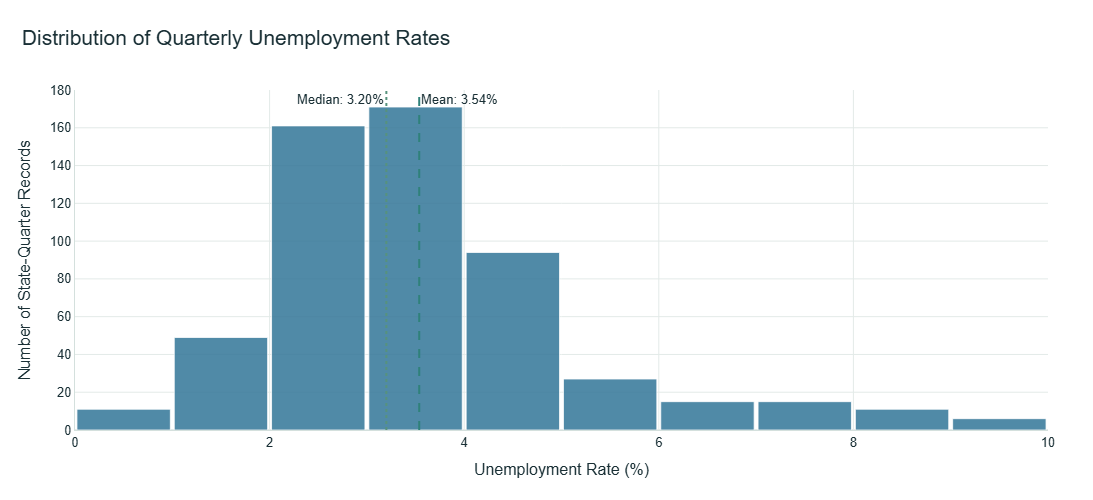

In [33]:
# CELL 31
# INTERACTIVE CHART 5:
# Distribution of quarterly unemployment rates.

interactive_mean = df_qtr["u_rate"].mean()
interactive_median = df_qtr["u_rate"].median()

histogram_figure = go.Figure()

histogram_figure.add_trace(
    go.Histogram(
        x=df_qtr["u_rate"],
        nbinsx=18,
        name="State-quarter records",
        marker={
            "color": ACCENT_COLORS["blue"],
            "line": {
                "color": "#FFFFFF",
                "width": 0.8
            }
        },
        opacity=0.88,
        hovertemplate=(
            "Unemployment-rate range: %{x}<br>"
            "Number of records: %{y}"
            "<extra></extra>"
        )
    )
)

histogram_figure.add_vline(
    x=interactive_mean,
    line_width=2,
    line_dash="dash",
    line_color=ACCENT_COLORS["teal"],
    annotation_text=(
        f"Mean: {interactive_mean:.2f}%"
    ),
    annotation_position="top right"
)

histogram_figure.add_vline(
    x=interactive_median,
    line_width=2,
    line_dash="dot",
    line_color=ACCENT_COLORS["green"],
    annotation_text=(
        f"Median: {interactive_median:.2f}%"
    ),
    annotation_position="top left"
)

histogram_figure.update_layout(
    title="Distribution of Quarterly Unemployment Rates",
    xaxis_title="Unemployment Rate (%)",
    yaxis_title="Number of State-Quarter Records",
    bargap=0.04,
    showlegend=False
)

apply_dashboard_theme(
    histogram_figure,
    theme="light",
    height=500
)

histogram_figure.show()

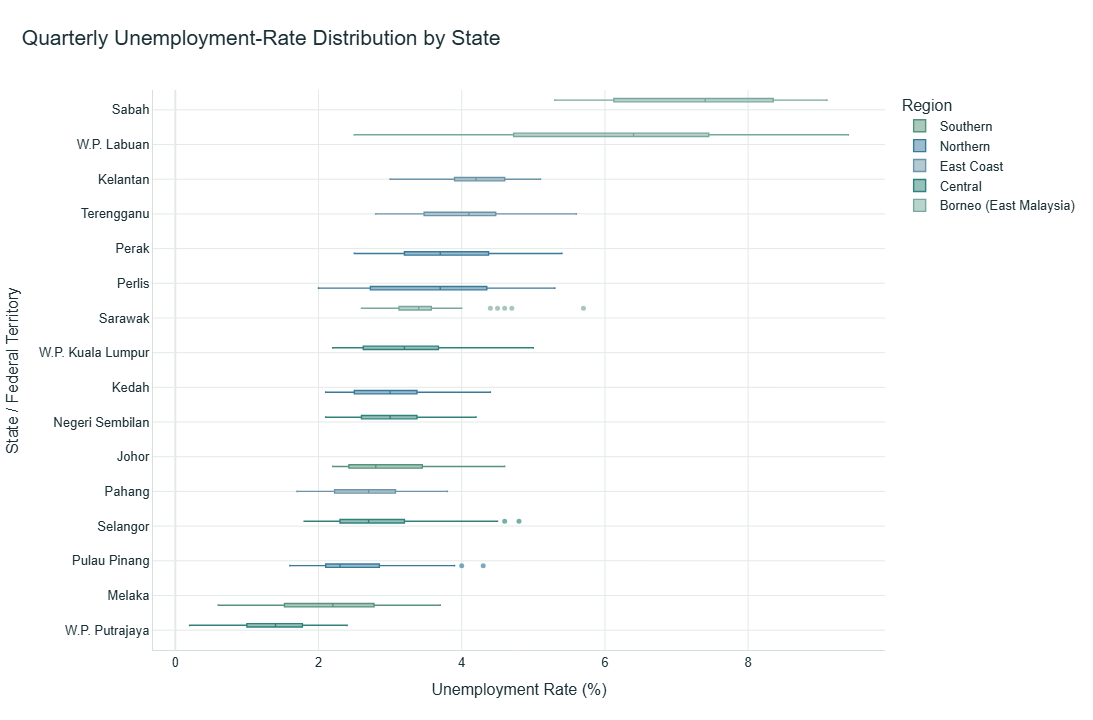

In [34]:
# CELL 32
# INTERACTIVE CHART 6:
# Quarterly unemployment-rate distributions by state.

interactive_state_order = (
    df_qtr
    .groupby("state")["u_rate"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

boxplot_figure = px.box(
    df_qtr,
    x="u_rate",
    y="state",
    color="region",
    points="outliers",
    category_orders={
        "state": interactive_state_order
    },
    color_discrete_map=REGION_COLORS,
    title=(
        "Quarterly Unemployment-Rate "
        "Distribution by State"
    ),
    labels={
        "u_rate": "Unemployment Rate (%)",
        "state": "State / Federal Territory",
        "region": "Region"
    },
    hover_data={
        "region": True
    }
)

boxplot_figure.update_traces(
    line={
        "width": 1.4
    },
    marker={
        "size": 5,
        "opacity": 0.65
    }
)

boxplot_figure.update_layout(
    legend_title_text="Region"
)

apply_dashboard_theme(
    boxplot_figure,
    theme="light",
    height=720
)

boxplot_figure.show()

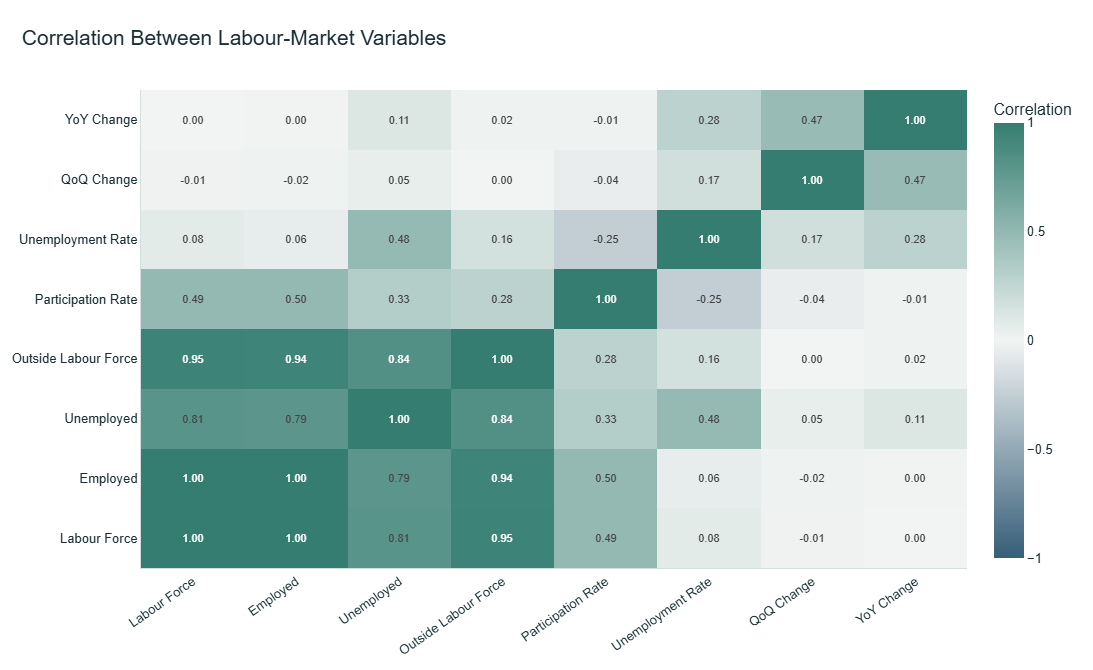

In [35]:
# CELL 33
# INTERACTIVE CHART 7:
# Correlation heatmap of labour-market variables.

heatmap_columns = [
    "lf",
    "lf_employed",
    "lf_unemployed",
    "lf_outside",
    "p_rate",
    "u_rate",
    "qoq_change_pp",
    "yoy_change_pp"
]

heatmap_labels = [
    "Labour Force",
    "Employed",
    "Unemployed",
    "Outside Labour Force",
    "Participation Rate",
    "Unemployment Rate",
    "QoQ Change",
    "YoY Change"
]

interactive_correlation = (
    df_qtr[heatmap_columns]
    .corr()
)

heatmap_figure = go.Figure(
    data=go.Heatmap(
        z=interactive_correlation.values,
        x=heatmap_labels,
        y=heatmap_labels,
        zmin=-1,
        zmax=1,
        zmid=0,
        colorscale=[
            [0.00, "#365E78"],
            [0.50, "#F1F4F3"],
            [1.00, "#347D70"]
        ],
        text=interactive_correlation.round(2).values,
        texttemplate="%{text:.2f}",
        textfont={
            "size": 11
        },
        colorbar={
            "title": "Correlation"
        },
        hovertemplate=(
            "%{y} vs %{x}<br>"
            "Correlation: %{z:.3f}"
            "<extra></extra>"
        )
    )
)

heatmap_figure.update_layout(
    title="Correlation Between Labour-Market Variables"
)

heatmap_figure.update_xaxes(
    tickangle=-35
)

apply_dashboard_theme(
    heatmap_figure,
    theme="light",
    height=670
)

heatmap_figure.show()

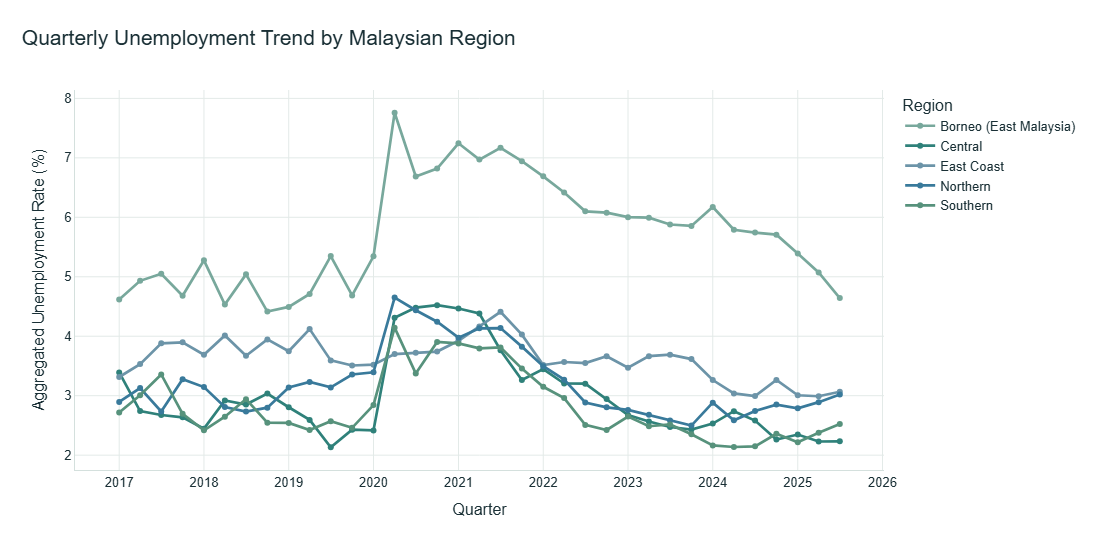

In [36]:
# CELL 34
# INTERACTIVE CHART 8:
# Quarterly unemployment trend by Malaysian region.

regional_trend_data = (
    df_qtr
    .groupby(
        ["date", "region"],
        as_index=False,
        observed=True
    )
    .agg(
        regional_labour_force=("lf", "sum"),
        regional_unemployed=(
            "lf_unemployed",
            "sum"
        )
    )
)

regional_trend_data["regional_u_rate"] = (
    regional_trend_data["regional_unemployed"]
    / regional_trend_data["regional_labour_force"]
    * 100
)

regional_trend_data["quarter_label"] = (
    regional_trend_data["date"]
    .dt.to_period("Q")
    .astype(str)
)

regional_figure = px.line(
    regional_trend_data,
    x="date",
    y="regional_u_rate",
    color="region",
    markers=True,
    color_discrete_map=REGION_COLORS,
    title=(
        "Quarterly Unemployment Trend "
        "by Malaysian Region"
    ),
    labels={
        "date": "Quarter",
        "regional_u_rate":
        "Aggregated Unemployment Rate (%)",
        "region": "Region"
    },
    custom_data=[
        "quarter_label",
        "regional_labour_force",
        "regional_unemployed"
    ]
)

regional_figure.update_traces(
    line={
        "width": 2.7
    },
    marker={
        "size": 6
    },
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Quarter: %{customdata[0]}<br>"
        "Unemployment rate: %{y:.2f}%<br>"
        "Labour force: %{customdata[1]:,.1f} thousand<br>"
        "Unemployed: %{customdata[2]:,.1f} thousand"
        "<extra></extra>"
    )
)

regional_figure.update_layout(
    legend_title_text="Region",
    hovermode="x unified"
)

apply_dashboard_theme(
    regional_figure,
    theme="light",
    height=540
)

regional_figure.show()

In [37]:
# CELL 35
# Build the final 8-view interactive dashboard.
# Includes:
# - Light and dark modes
# - Readable chart text and axis titles in both modes
# - Restrained teal-blue neon accents
# - Eight interactive dashboard views
# - Offline Plotly support
# - Responsive dashboard layout

import plotly.io as pio
import plotly.graph_objects as go


# ============================================================
# 1. RECALCULATE DASHBOARD SUMMARY VALUES
# ============================================================

latest_date = df_qtr["date"].max()

latest_state_data = (
    df_qtr[df_qtr["date"] == latest_date]
    .sort_values("u_rate", ascending=False)
    .copy()
)

latest_quarter_label = str(
    latest_date.to_period("Q")
)

latest_average_rate = (
    latest_state_data["u_rate"].mean()
)

highest_latest_row = latest_state_data.iloc[0]
lowest_latest_row = latest_state_data.iloc[-1]

quarterly_summary = (
    df_qtr
    .groupby("date", as_index=False)
    .agg(
        average_state_rate=("u_rate", "mean")
    )
)

peak_dashboard_row = quarterly_summary.loc[
    quarterly_summary["average_state_rate"].idxmax()
]

dashboard_correlation = (
    df_qtr["p_rate"].corr(
        df_qtr["u_rate"]
    )
)

latest_complete_gender = (
    gender_pivot
    .dropna(subset=["female", "male"])
    .index.max()
)

latest_female_rate = gender_pivot.loc[
    latest_complete_gender,
    "female"
]

latest_male_rate = gender_pivot.loc[
    latest_complete_gender,
    "male"
]

latest_gender_gap = (
    latest_female_rate
    - latest_male_rate
)


# ============================================================
# 2. ORIGINAL FIGURE COLOURS
# ============================================================

# Dashboard interface accents are kept separate from chart colours.
# This allows the page to retain its green-blue visual identity while
# the charts use the clearer colours from the original saved figures.

UI_ACCENT_TEAL = "#2F9789"

# Seaborn "deep" palette used by the original region-based figures.
ORIGINAL_REGION_COLORS = {
    "Borneo (East Malaysia)": "#4C72B0",  # Blue
    "East Coast": "#DD8452",              # Orange
    "Northern": "#55A868",                # Green
    "Central": "#C44E52",                 # Red
    "Southern": "#8172B2"                 # Purple
}

# Original colours used by the earlier static figures.
TREND_LINE_COLOR = "#4C72B0"
BOXPLOT_COLOR = "#56CCF2"
HISTOGRAM_COLOR = "#2F80ED"
MEAN_LINE_COLOR = "#EB5757"
MEDIAN_LINE_COLOR = "#27AE60"
MALE_COLOR = "#4C72B0"
FEMALE_COLOR = "#DD8452"


# ============================================================
# 3. APPLY CONSISTENT INITIAL LIGHT STYLE
# ============================================================

def apply_initial_light_style(
    figure,
    height=None
):
    """
    Apply the dashboard's initial light appearance.

    The HTML JavaScript later changes these values when
    the user selects dark mode.
    """

    layout_changes = {
        "paper_bgcolor": "#FFFFFF",
        "plot_bgcolor": "#FFFFFF",
        "font": {
            "family": (
                "Inter, Arial, Helvetica, sans-serif"
            ),
            "color": "#183238",
            "size": 13
        },
        "title": {
            "font": {
                "color": "#183238",
                "size": 21
            },
            "x": 0.02,
            "xanchor": "left"
        },
        "legend": {
            "font": {
                "color": "#183238"
            },
            "title": {
                "font": {
                    "color": "#183238"
                }
            }
        },
        "hoverlabel": {
            "bgcolor": "#FFFFFF",
            "font": {
                "color": "#183238"
            },
            "bordercolor": UI_ACCENT_TEAL
        }
    }

    if height is not None:
        layout_changes["height"] = height

    figure.update_layout(
        **layout_changes
    )

    figure.update_xaxes(
        color="#183238",
        gridcolor="#E3EAE8",
        zerolinecolor="#E3EAE8",
        linecolor="#D4E0DD",
        tickfont={
            "color": "#183238"
        },
        title_font={
            "color": "#183238"
        }
    )

    figure.update_yaxes(
        color="#183238",
        gridcolor="#E3EAE8",
        zerolinecolor="#E3EAE8",
        linecolor="#D4E0DD",
        tickfont={
            "color": "#183238"
        },
        title_font={
            "color": "#183238"
        }
    )

    return figure


# Apply the initial style to all eight charts.

apply_initial_light_style(
    trend_figure,
    height=540
)

apply_initial_light_style(
    regional_figure,
    height=540
)

apply_initial_light_style(
    ranking_figure,
    height=650
)

apply_initial_light_style(
    boxplot_figure,
    height=720
)

apply_initial_light_style(
    scatter_figure,
    height=610
)

apply_initial_light_style(
    histogram_figure,
    height=510
)

apply_initial_light_style(
    heatmap_figure,
    height=680
)

apply_initial_light_style(
    gender_figure,
    height=520
)


# ============================================================
# 4. RESTORE THE ORIGINAL FIGURE COLOURS
# ============================================================

# ------------------------------------------------------------
# Trend chart
# ------------------------------------------------------------

# The dropdown displays only one trend at a time, so the average and
# individual-state traces all use the original blue line colour.

for trace in trend_figure.data:
    trace.line.color = TREND_LINE_COLOR
    trace.marker.color = TREND_LINE_COLOR


# Move the trend dropdown to the top-right so it does not cover
# the chart title.

if trend_figure.layout.updatemenus:

    trend_menu = (
        trend_figure
        .layout
        .updatemenus[0]
        .to_plotly_json()
    )

    trend_menu.update({
        "x": 0.99,
        "xanchor": "right",
        "y": 1.17,
        "yanchor": "top",
        "bgcolor": "#FFFFFF",
        "bordercolor": "#D4E0DD",
        "font": {
            "color": "#183238",
            "size": 12
        }
    })

    trend_figure.update_layout(
        updatemenus=[trend_menu],
        margin={
            "l": 75,
            "r": 45,
            "t": 145,
            "b": 75
        }
    )


# ------------------------------------------------------------
# Regional trend chart
# ------------------------------------------------------------

for trace in regional_figure.data:

    if trace.name in ORIGINAL_REGION_COLORS:

        selected_color = ORIGINAL_REGION_COLORS[
            trace.name
        ]

        trace.line.color = selected_color
        trace.marker.color = selected_color


# ------------------------------------------------------------
# Latest-quarter state ranking
# ------------------------------------------------------------

for trace in ranking_figure.data:

    if trace.name in ORIGINAL_REGION_COLORS:

        trace.marker.color = ORIGINAL_REGION_COLORS[
            trace.name
        ]


# ------------------------------------------------------------
# State box plot
# ------------------------------------------------------------

# Rebuild the box plot with one proper filled box per state.
# Each region has a distinct colour, making the distributions
# much easier to read than the previous thin-line appearance.

def hex_to_rgba(hex_colour, opacity=0.38):
    """Convert a hexadecimal colour into an RGBA colour."""

    hex_colour = hex_colour.lstrip("#")

    red = int(hex_colour[0:2], 16)
    green = int(hex_colour[2:4], 16)
    blue = int(hex_colour[4:6], 16)

    return (
        f"rgba({red}, {green}, {blue}, {opacity})"
    )


boxplot_state_order = (
    df_qtr
    .groupby("state")["u_rate"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)


boxplot_figure = go.Figure()

regions_already_shown = set()


for state in boxplot_state_order:

    state_data = (
        df_qtr[df_qtr["state"] == state]
        .sort_values("date")
        .copy()
    )

    state_region = (
        state_data["region"]
        .mode()
        .iloc[0]
    )

    state_colour = ORIGINAL_REGION_COLORS.get(
        state_region,
        "#6C91A7"
    )

    show_region_legend = (
        state_region not in regions_already_shown
    )

    boxplot_figure.add_trace(
        go.Box(
            x=state_data["u_rate"],
            y=[state] * len(state_data),

            name=state_region,
            legendgroup=state_region,
            showlegend=show_region_legend,

            orientation="h",

            line={
                "color": state_colour,
                "width": 2
            },

            fillcolor=hex_to_rgba(
                state_colour,
                opacity=0.42
            ),

            marker={
                "color": state_colour,
                "size": 6,
                "opacity": 0.88,
                "line": {
                    "color": "#FFFFFF",
                    "width": 0.6
                }
            },

            boxpoints="outliers",
            jitter=0.18,
            pointpos=0,
            whiskerwidth=0.75,
            width=0.58,

            customdata=state_data[
                ["date", "region"]
            ].assign(
                quarter=lambda frame: (
                    frame["date"]
                    .dt.to_period("Q")
                    .astype(str)
                )
            )[["quarter", "region"]].to_numpy(),

            hovertemplate=(
                f"<b>{state}</b><br>"
                f"Region: {state_region}<br>"
                "Unemployment rate: %{x:.1f}%"
                "<extra></extra>"
            )
        )
    )

    regions_already_shown.add(
        state_region
    )


boxplot_figure.update_layout(
    title=(
        "Quarterly Unemployment-Rate "
        "Distribution by State"
    ),

    xaxis_title="Unemployment Rate (%)",

    yaxis_title=(
        "State / Federal Territory"
    ),

    boxmode="overlay",

    legend={
        "title": {
            "text": "Region"
        },
        "orientation": "v",
        "x": 1.01,
        "xanchor": "left",
        "y": 1,
        "yanchor": "top"
    },

    margin={
        "l": 155,
        "r": 190,
        "t": 90,
        "b": 75
    }
)


boxplot_figure.update_yaxes(
    categoryorder="array",
    categoryarray=boxplot_state_order,
    autorange="reversed"
)


apply_initial_light_style(
    boxplot_figure,
    height=760
)


# ------------------------------------------------------------
# Animated participation-unemployment scatter plot
# ------------------------------------------------------------

# Update the initial traces.

for trace in scatter_figure.data:

    if trace.name in ORIGINAL_REGION_COLORS:

        trace.marker.color = ORIGINAL_REGION_COLORS[
            trace.name
        ]


# Update every animation frame as well. Without this block, the
# region colours would revert when the Play button is pressed.

for frame in scatter_figure.frames:

    for trace in frame.data:

        trace_name = getattr(
            trace,
            "name",
            None
        )

        if trace_name in ORIGINAL_REGION_COLORS:

            trace.marker.color = (
                ORIGINAL_REGION_COLORS[
                    trace_name
                ]
            )


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

if len(histogram_figure.data) > 0:

    histogram_figure.data[0].marker.color = (
        HISTOGRAM_COLOR
    )

    histogram_figure.data[0].marker.line.color = (
        "#FFFFFF"
    )


# Restore the original red mean line and green median line.

if histogram_figure.layout.shapes:

    if len(histogram_figure.layout.shapes) >= 1:
        histogram_figure.layout.shapes[
            0
        ].line.color = MEAN_LINE_COLOR

    if len(histogram_figure.layout.shapes) >= 2:
        histogram_figure.layout.shapes[
            1
        ].line.color = MEDIAN_LINE_COLOR


# Restore matching colours for the mean and median labels.

if histogram_figure.layout.annotations:

    for annotation in histogram_figure.layout.annotations:

        annotation_text = str(
            annotation.text
        )

        if "Mean" in annotation_text:
            annotation.font.color = MEAN_LINE_COLOR

        elif "Median" in annotation_text:
            annotation.font.color = MEDIAN_LINE_COLOR


# ------------------------------------------------------------
# Correlation heatmap
# ------------------------------------------------------------

# Matplotlib used the Viridis colour map for the original heatmap.

if len(heatmap_figure.data) > 0:

    heatmap_figure.data[0].colorscale = "Viridis"


# ------------------------------------------------------------
# Gender trend
# ------------------------------------------------------------

# The original line chart used blue for male and orange for female.

for trace in gender_figure.data:

    trace_name = str(
        trace.name
    ).lower()

    if trace_name == "male":

        trace.line.color = MALE_COLOR
        trace.marker.color = MALE_COLOR

    elif trace_name == "female":

        trace.line.color = FEMALE_COLOR
        trace.marker.color = FEMALE_COLOR


# ============================================================
# 5. PLOTLY EXPORT CONFIGURATION
# ============================================================

plotly_config = {
    "responsive": True,
    "displaylogo": False,
    "scrollZoom": False,
    "modeBarButtonsToRemove": [
        "lasso2d",
        "select2d"
    ],
    "toImageButtonOptions": {
        "format": "png",
        "filename": (
            "tdw_unemployment_chart"
        ),
        "height": 700,
        "width": 1200,
        "scale": 2
    }
}


# ============================================================
# 6. CONVERT ALL EIGHT PLOTLY FIGURES TO HTML
# ============================================================

# Plotly JavaScript is included only once.
# "inline" allows the dashboard to work offline.

trend_html = pio.to_html(
    trend_figure,
    full_html=False,
    include_plotlyjs="inline",
    config=plotly_config,
    div_id="trend-chart"
)

regional_html = pio.to_html(
    regional_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="regional-chart"
)

ranking_html = pio.to_html(
    ranking_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="ranking-chart"
)

boxplot_html = pio.to_html(
    boxplot_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="boxplot-chart"
)

scatter_html = pio.to_html(
    scatter_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="scatter-chart"
)

histogram_html = pio.to_html(
    histogram_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="histogram-chart"
)

heatmap_html = pio.to_html(
    heatmap_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="heatmap-chart"
)

gender_html = pio.to_html(
    gender_figure,
    full_html=False,
    include_plotlyjs=False,
    config=plotly_config,
    div_id="gender-chart"
)


# ============================================================
# 7. CREATE DASHBOARD HTML TEMPLATE
# ============================================================

dashboard_template = """
<!DOCTYPE html>

<html lang="en" data-theme="light">

<head>

    <meta charset="UTF-8">

    <meta
        name="viewport"
        content="width=device-width, initial-scale=1.0"
    >

    <title>
        Malaysia Unemployment Dashboard
    </title>

    <style>

        :root {
            --page-bg: #F2F6F5;
            --surface: #FFFFFF;
            --surface-soft: #F8FAF9;
            --text: #183238;
            --muted: #667A7F;
            --border: #D7E2DF;
            --shadow: rgba(25, 54, 61, 0.09);

            --accent: #2F9789;
            --accent-blue: #4385B5;
            --accent-soft: #E4F2EF;
            --accent-glow:
                rgba(47, 151, 137, 0.14);

            --header-start: #17363D;
            --header-end: #245F68;
        }


        html[data-theme="dark"] {
            --page-bg: #0D181C;
            --surface: #14252B;
            --surface-soft: #192E34;
            --text: #F1FAF8;
            --muted: #ADC4BF;
            --border: #355159;
            --shadow: rgba(0, 0, 0, 0.30);

            --accent: #34D6C2;
            --accent-blue: #55A7FF;
            --accent-soft: #19383C;
            --accent-glow:
                rgba(52, 214, 194, 0.20);

            --header-start: #0F252B;
            --header-end: #16424B;
        }


        * {
            box-sizing: border-box;
        }


        html {
            scroll-behavior: smooth;
        }


        body {
            margin: 0;

            background:
                radial-gradient(
                    circle at 90% 5%,
                    var(--accent-glow),
                    transparent 24%
                ),
                var(--page-bg);

            color: var(--text);

            font-family:
                Inter,
                Arial,
                Helvetica,
                sans-serif;

            transition:
                background 0.25s ease,
                color 0.25s ease;
        }


        .top-bar {
            position: sticky;
            top: 0;
            z-index: 1000;

            display: flex;
            align-items: center;
            justify-content: space-between;
            gap: 20px;

            padding: 13px 4%;

            background:
                color-mix(
                    in srgb,
                    var(--surface) 96%,
                    transparent
                );

            border-bottom:
                1px solid var(--border);

            box-shadow:
                0 4px 18px var(--shadow);

            backdrop-filter:
                blur(10px);
        }


        .brand {
            color: var(--text);
            font-size: 15px;
            font-weight: 700;
            letter-spacing: 0.3px;
        }


        .brand::before {
            display: inline-block;

            width: 8px;
            height: 8px;

            margin-right: 9px;

            content: "";

            background:
                linear-gradient(
                    135deg,
                    var(--accent),
                    var(--accent-blue)
                );

            border-radius: 50%;

            box-shadow:
                0 0 9px var(--accent-glow);
        }


        .theme-button {
            padding: 9px 15px;

            color: var(--text);
            background: transparent;

            border:
                1px solid var(--border);

            border-radius: 8px;

            font-size: 13px;
            font-weight: 600;

            cursor: pointer;

            transition:
                background 0.2s ease,
                border-color 0.2s ease,
                box-shadow 0.2s ease;
        }


        .theme-button:hover {
            background: var(--accent-soft);
            border-color: var(--accent);

            box-shadow:
                0 0 13px var(--accent-glow);
        }


        .hero {
            position: relative;
            overflow: hidden;

            padding: 59px 5% 53px;

            color: #F4FAF8;

            background:
                radial-gradient(
                    circle at 82% 18%,
                    rgba(85, 167, 255, 0.16),
                    transparent 31%
                ),
                radial-gradient(
                    circle at 68% 80%,
                    rgba(52, 214, 194, 0.12),
                    transparent 30%
                ),
                linear-gradient(
                    120deg,
                    var(--header-start),
                    var(--header-end)
                );

            border-bottom:
                4px solid var(--accent);
        }


        .hero::after {
            position: absolute;
            right: -90px;
            bottom: -130px;

            width: 350px;
            height: 350px;

            content: "";

            border:
                1px solid rgba(
                    255,
                    255,
                    255,
                    0.09
                );

            border-radius: 50%;
        }


        .hero-inner {
            position: relative;
            z-index: 1;

            width: min(1400px, 100%);
            margin: auto;
        }


        .eyebrow {
            margin-bottom: 12px;

            color: #A7E6DB;

            font-size: 13px;
            font-weight: 700;
            letter-spacing: 1.5px;
            text-transform: uppercase;
        }


        .hero h1 {
            max-width: 850px;
            margin: 0;

            font-size:
                clamp(
                    32px,
                    5vw,
                    54px
                );

            line-height: 1.08;
            letter-spacing: -1.5px;
        }


        .hero p {
            max-width: 850px;
            margin: 19px 0 0;

            color: #D6E9E5;

            font-size: 17px;
            line-height: 1.7;
        }


        .container {
            width: min(1420px, 94%);
            margin: 30px auto 55px;
        }


        .navigation {
            display: flex;
            flex-wrap: wrap;
            gap: 10px;

            margin-bottom: 27px;
        }


        .navigation a {
            padding: 9px 14px;

            color: var(--text);
            background: var(--surface);

            border:
                1px solid var(--border);

            border-radius: 8px;

            font-size: 13px;
            font-weight: 600;
            text-decoration: none;

            box-shadow:
                0 3px 10px var(--shadow);

            transition:
                color 0.2s ease,
                border-color 0.2s ease,
                box-shadow 0.2s ease;
        }


        .navigation a:hover {
            color: var(--accent);
            border-color: var(--accent);

            box-shadow:
                0 0 12px var(--accent-glow);
        }


        .metric-grid {
            display: grid;

            grid-template-columns:
                repeat(
                    auto-fit,
                    minmax(205px, 1fr)
                );

            gap: 16px;

            margin-bottom: 26px;
        }


        .metric-card {
            position: relative;
            overflow: hidden;

            padding: 21px;

            background: var(--surface);

            border:
                1px solid var(--border);

            border-radius: 12px;

            box-shadow:
                0 5px 18px var(--shadow);

            transition:
                transform 0.2s ease,
                border-color 0.2s ease,
                box-shadow 0.2s ease;
        }


        .metric-card:hover {
            transform:
                translateY(-2px);

            border-color:
                color-mix(
                    in srgb,
                    var(--accent) 55%,
                    var(--border)
                );

            box-shadow:
                0 8px 23px var(--shadow),
                0 0 13px var(--accent-glow);
        }


        .metric-card::before {
            position: absolute;
            top: 0;
            left: 0;

            width: 100%;
            height: 4px;

            content: "";

            background:
                linear-gradient(
                    90deg,
                    var(--accent),
                    var(--accent-blue)
                );

            box-shadow:
                0 0 12px var(--accent-glow);
        }


        .metric-label {
            margin-bottom: 9px;

            color: var(--muted);

            font-size: 12px;
            font-weight: 700;
            letter-spacing: 0.7px;
            text-transform: uppercase;
        }


        .metric-value {
            color: var(--text);

            font-size: 27px;
            font-weight: 700;
        }


        .metric-note {
            margin-top: 7px;

            color: var(--muted);

            font-size: 13px;
            line-height: 1.45;
        }


        .summary-panel {
            margin-bottom: 27px;
            padding: 22px 24px;

            background:
                linear-gradient(
                    100deg,
                    var(--accent-soft),
                    var(--surface)
                );

            border:
                1px solid var(--border);

            border-left:
                5px solid var(--accent);

            border-radius: 10px;

            color: var(--text);
            line-height: 1.7;

            box-shadow:
                0 4px 14px var(--shadow);
        }


        .section-heading {
            margin: 45px 0 18px;
        }


        .section-heading span {
            color: var(--accent);

            font-size: 12px;
            font-weight: 700;
            letter-spacing: 1.3px;
            text-transform: uppercase;
        }


        .section-heading h2 {
            margin: 7px 0 0;

            color: var(--text);

            font-size: 27px;
        }


        .chart-card {
            margin-bottom: 24px;
            padding: 23px;

            background: var(--surface);

            border:
                1px solid var(--border);

            border-radius: 14px;

            box-shadow:
                0 6px 20px var(--shadow);

            transition:
                border-color 0.2s ease,
                box-shadow 0.2s ease;
        }


        .chart-card:hover {
            border-color:
                color-mix(
                    in srgb,
                    var(--accent) 38%,
                    var(--border)
                );

            box-shadow:
                0 8px 26px var(--shadow),
                0 0 12px var(--accent-glow);
        }


        .chart-header {
            margin-bottom: 8px;
        }


        .chart-number {
            display: inline-block;

            margin-bottom: 7px;

            color: var(--accent);

            font-size: 12px;
            font-weight: 700;
            letter-spacing: 1px;
            text-transform: uppercase;
        }


        .chart-header h3 {
            margin: 0 0 8px;

            color: var(--text);

            font-size: 21px;
        }


        .chart-header p {
            max-width: 950px;
            margin: 0;

            color: var(--muted);

            font-size: 14px;
            line-height: 1.6;
        }


        .chart-wrapper {
            width: 100%;
            overflow: hidden;
        }


        .data-note {
            margin-top: 31px;
            padding: 23px 25px;

            background: var(--surface);

            border:
                1px solid var(--border);

            border-left:
                5px solid var(--accent-blue);

            border-radius: 11px;

            color: var(--muted);

            font-size: 14px;
            line-height: 1.7;

            box-shadow:
                0 5px 18px var(--shadow);
        }


        footer {
            padding: 28px 20px;

            color: var(--muted);
            text-align: center;

            border-top:
                1px solid var(--border);

            font-size: 13px;
        }


        @media (max-width: 700px) {

            .top-bar {
                padding: 12px 18px;
            }

            .brand {
                font-size: 13px;
            }

            .hero {
                padding: 42px 23px;
            }

            .chart-card {
                padding: 13px;
            }

            .container {
                width: 96%;
            }
        }

    </style>

</head>


<body>

    <div class="top-bar">

        <div class="brand">
            TDW · Malaysia Labour Market
        </div>

        <button
            id="themeToggle"
            class="theme-button"
            type="button"
            aria-label="Switch dashboard theme"
        >
            ◐ Dark mode
        </button>

    </div>


    <header class="hero">

        <div class="hero-inner">

            <div class="eyebrow">
                Interactive Data Story
            </div>

            <h1>
                Unemployment Rate in Malaysia
            </h1>

            <p>
                Quarterly unemployment patterns across Malaysian
                states and federal territories, supported by regional,
                distributional and annual gender perspectives.
            </p>

        </div>

    </header>


    <main class="container">

        <nav class="navigation">

            <a href="#overview">
                Overview
            </a>

            <a href="#trends">
                Trends
            </a>

            <a href="#states">
                State comparison
            </a>

            <a href="#relationships">
                Relationships
            </a>

            <a href="#gender">
                Gender analysis
            </a>

        </nav>


        <section
            id="overview"
            class="metric-grid"
        >

            <div class="metric-card">

                <div class="metric-label">
                    Latest quarter
                </div>

                <div class="metric-value">
                    [[LATEST_QUARTER]]
                </div>

                <div class="metric-note">
                    Most recent quarterly record
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-label">
                    Average state rate
                </div>

                <div class="metric-value">
                    [[LATEST_AVERAGE]]%
                </div>

                <div class="metric-note">
                    Unweighted average across
                    16 states and FTs
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-label">
                    Highest rate
                </div>

                <div class="metric-value">
                    [[HIGHEST_RATE]]%
                </div>

                <div class="metric-note">
                    [[HIGHEST_STATE]]
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-label">
                    Lowest rate
                </div>

                <div class="metric-value">
                    [[LOWEST_RATE]]%
                </div>

                <div class="metric-note">
                    [[LOWEST_STATE]]
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-label">
                    Participation correlation
                </div>

                <div class="metric-value">
                    [[CORRELATION]]
                </div>

                <div class="metric-note">
                    Relationship with
                    unemployment rate
                </div>

            </div>

        </section>


        <div class="summary-panel">

            <strong>
                Latest snapshot:
            </strong>

            In [[LATEST_QUARTER]],
            [[HIGHEST_STATE]] recorded the highest
            unemployment rate at [[HIGHEST_RATE]]%,
            while [[LOWEST_STATE]] recorded the lowest
            rate at [[LOWEST_RATE]]%.

            The average across the 16 states and federal
            territories was [[LATEST_AVERAGE]]%.

        </div>


        <div
            id="trends"
            class="section-heading"
        >

            <span>
                Section 01
            </span>

            <h2>
                Unemployment trends over time
            </h2>

        </div>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 01
                </span>

                <h3>
                    Quarterly state unemployment trend
                </h3>

                <p>
                    Use the dropdown to compare the average
                    across all states with any individual state
                    or federal territory.
                </p>

            </div>

            <div class="chart-wrapper">
                [[TREND_CHART]]
            </div>

        </section>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 02
                </span>

                <h3>
                    Regional unemployment trend
                </h3>

                <p>
                    Compares aggregated unemployment rates
                    across the five Malaysian regions using
                    labour-force totals.
                </p>

            </div>

            <div class="chart-wrapper">
                [[REGIONAL_CHART]]
            </div>

        </section>


        <div
            id="states"
            class="section-heading"
        >

            <span>
                Section 02
            </span>

            <h2>
                State-level comparison
            </h2>

        </div>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 03
                </span>

                <h3>
                    Latest-quarter state ranking
                </h3>

                <p>
                    Hover over each bar to inspect
                    unemployment, participation and
                    labour-force values.
                </p>

            </div>

            <div class="chart-wrapper">
                [[RANKING_CHART]]
            </div>

        </section>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 04
                </span>

                <h3>
                    State unemployment distributions
                </h3>

                <p>
                    Each box summarises all quarterly unemployment
                    rates for one state. The box shows the middle 50%,
                    the centre line shows the median, the whiskers show
                    the usual range, and separate dots represent
                    unusual quarterly observations.
                </p>

            </div>

            <div class="chart-wrapper">
                [[BOXPLOT_CHART]]
            </div>

        </section>


        <div
            id="relationships"
            class="section-heading"
        >

            <span>
                Section 03
            </span>

            <h2>
                Patterns and statistical relationships
            </h2>

        </div>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 05
                </span>

                <h3>
                    Participation versus unemployment
                </h3>

                <p>
                    Press Play or use the quarter slider.
                    Bubble size represents the total
                    labour force.
                </p>

            </div>

            <div class="chart-wrapper">
                [[SCATTER_CHART]]
            </div>

        </section>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 06
                </span>

                <h3>
                    Distribution of unemployment rates
                </h3>

                <p>
                    Displays how frequently different
                    unemployment rates occur across all
                    state-quarter records.
                </p>

            </div>

            <div class="chart-wrapper">
                [[HISTOGRAM_CHART]]
            </div>

        </section>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 07
                </span>

                <h3>
                    Labour-market correlation heatmap
                </h3>

                <p>
                    Shows the direction and strength of
                    relationships among the main numerical
                    variables.
                </p>

            </div>

            <div class="chart-wrapper">
                [[HEATMAP_CHART]]
            </div>

        </section>


        <div
            id="gender"
            class="section-heading"
        >

            <span>
                Section 04
            </span>

            <h2>
                Supporting gender analysis
            </h2>

        </div>


        <section class="chart-card">

            <div class="chart-header">

                <span class="chart-number">
                    View 08
                </span>

                <h3>
                    Annual unemployment trend by sex
                </h3>

                <p>
                    Latest complete year:
                    [[GENDER_YEAR]].

                    Female rate:
                    [[FEMALE_RATE]]%.

                    Male rate:
                    [[MALE_RATE]]%.

                    Difference:
                    [[GENDER_GAP]]
                    percentage points.
                </p>

            </div>

            <div class="chart-wrapper">
                [[GENDER_CHART]]
            </div>

        </section>


        <div class="data-note">

            <strong>
                Data notes:
            </strong>

            The quarterly state average is not Malaysia's
            official national unemployment rate because
            each state receives equal weight.

            The annual gender dataset is analysed separately
            from the quarterly dataset.

            Negeri Sembilan is excluded from the male-female
            comparison because separate sex records are
            unavailable.

            Historical gaps in 1991 and 1994 originate from
            the source data.

        </div>

    </main>


    <footer>
        TDW Project · UI/UX Specialist and Visual Storyteller
    </footer>


    <script>

        const themeButton =
            document.getElementById(
                "themeToggle"
            );

        const root =
            document.documentElement;


        const plotThemes = {

            light: {
                surface: "#FFFFFF",
                text: "#183238",
                muted: "#667A7F",
                grid: "#E3EAE8",
                border: "#D4E0DD",
                menuBackground: "#FFFFFF",
                activeBackground: "#E4F2EF",
                heatmapMiddle: "#F2F6F5",
                heatmapText: "#183238"
            },

            dark: {
                surface: "#14252B",
                text: "#F1FAF8",
                muted: "#ADC4BF",
                grid: "#30474E",
                border: "#3D5C64",
                menuBackground: "#1A3036",
                activeBackground: "#214B4D",
                heatmapMiddle: "#1A2F34",
                heatmapText: "#F1FAF8"
            }

        };


        function updatePlotTheme(mode) {

            const theme =
                plotThemes[mode];


            document
                .querySelectorAll(
                    ".js-plotly-plot"
                )
                .forEach((plot) => {

                    const updates = {
                        paper_bgcolor:
                            theme.surface,

                        plot_bgcolor:
                            theme.surface,

                        "font.color":
                            theme.text,

                        "title.font.color":
                            theme.text,

                        "legend.font.color":
                            theme.text,

                        "legend.title.font.color":
                            theme.text,

                        "hoverlabel.bgcolor":
                            theme.menuBackground,

                        "hoverlabel.font.color":
                            theme.text,

                        "hoverlabel.bordercolor":
                            mode === "dark"
                                ? "#34D6C2"
                                : "#2F9789"
                    };


                    /*
                    Update every x-axis and y-axis.

                    This fixes:
                    - axis titles
                    - axis tick labels
                    - axis lines
                    - grid lines
                    - animated chart axes
                    */

                    Object
                        .keys(plot.layout)
                        .filter((key) => (
                            /^xaxis\\d*$/.test(key)
                            ||
                            /^yaxis\\d*$/.test(key)
                        ))
                        .forEach((axisName) => {

                            updates[
                                `${axisName}.color`
                            ] = theme.text;

                            updates[
                                `${axisName}.tickfont.color`
                            ] = theme.text;

                            updates[
                                `${axisName}.title.font.color`
                            ] = theme.text;

                            updates[
                                `${axisName}.gridcolor`
                            ] = theme.grid;

                            updates[
                                `${axisName}.zerolinecolor`
                            ] = theme.grid;

                            updates[
                                `${axisName}.linecolor`
                            ] = theme.border;
                        });


                    const annotations =
                        plot.layout.annotations || [];

                    annotations.forEach(
                        (item, index) => {

                            updates[
                                `annotations[${index}].font.color`
                            ] = theme.text;

                            if (
                                item.arrowcolor
                                !== undefined
                            ) {
                                updates[
                                    `annotations[${index}].arrowcolor`
                                ] = theme.text;
                            }
                        }
                    );


                    const menus =
                        plot.layout.updatemenus || [];

                    menus.forEach(
                        (item, index) => {

                            updates[
                                `updatemenus[${index}].bgcolor`
                            ] = theme.menuBackground;

                            updates[
                                `updatemenus[${index}].bordercolor`
                            ] = theme.border;

                            updates[
                                `updatemenus[${index}].font.color`
                            ] = theme.text;

                            updates[
                                `updatemenus[${index}].activebgcolor`
                            ] = theme.activeBackground;
                        }
                    );


                    const sliders =
                        plot.layout.sliders || [];

                    sliders.forEach(
                        (item, index) => {

                            updates[
                                `sliders[${index}].font.color`
                            ] = theme.text;

                            updates[
                                `sliders[${index}].currentvalue.font.color`
                            ] = theme.text;

                            updates[
                                `sliders[${index}].bordercolor`
                            ] = theme.border;

                            updates[
                                `sliders[${index}].bgcolor`
                            ] = theme.menuBackground;

                            updates[
                                `sliders[${index}].activebgcolor`
                            ] = (
                                mode === "dark"
                                    ? "#34D6C2"
                                    : "#2F9789"
                            );

                            updates[
                                `sliders[${index}].tickcolor`
                            ] = theme.border;
                        }
                    );


                    Plotly.relayout(
                        plot,
                        updates
                    );

                });


            /*
            Keep the original Viridis heatmap colours in both themes.
            Only the heatmap text and colour-bar labels change when
            switching between light and dark mode.
            */

            const heatmap =
                document.getElementById(
                    "heatmap-chart"
                );


            if (heatmap) {

                Plotly.restyle(
                    heatmap,
                    {
                        "textfont.color":
                            theme.heatmapText,

                        "colorbar.tickfont.color":
                            theme.text,

                        "colorbar.title.font.color":
                            theme.text
                    },
                    [0]
                );
            }

        }


        function setDashboardTheme(mode) {

            root.setAttribute(
                "data-theme",
                mode
            );


            localStorage.setItem(
                "tdw-dashboard-theme",
                mode
            );


            themeButton.textContent =
                mode === "dark"
                    ? "☀ Light mode"
                    : "◐ Dark mode";


            /*
            Run twice to ensure Plotly has fully loaded
            every interactive chart and animation frame.
            */

            window.requestAnimationFrame(
                () => {

                    updatePlotTheme(mode);

                    window.setTimeout(
                        () => {
                            updatePlotTheme(mode);
                        },
                        100
                    );
                }
            );

        }


        themeButton.addEventListener(
            "click",
            () => {

                const current =
                    root.getAttribute(
                        "data-theme"
                    );

                const next =
                    current === "dark"
                        ? "light"
                        : "dark";

                setDashboardTheme(next);

            }
        );


        window.addEventListener(
            "load",
            () => {

                const savedTheme =
                    localStorage.getItem(
                        "tdw-dashboard-theme"
                    )
                    || "light";

                setDashboardTheme(
                    savedTheme
                );

            }
        );

    </script>

</body>

</html>
"""


# ============================================================
# 8. INSERT VALUES AND CHARTS INTO THE HTML TEMPLATE
# ============================================================

dashboard_html = dashboard_template


replacements = {

    "[[LATEST_QUARTER]]":
        latest_quarter_label,

    "[[LATEST_AVERAGE]]":
        f"{latest_average_rate:.2f}",

    "[[HIGHEST_RATE]]":
        f"{highest_latest_row['u_rate']:.1f}",

    "[[HIGHEST_STATE]]":
        str(highest_latest_row["state"]),

    "[[LOWEST_RATE]]":
        f"{lowest_latest_row['u_rate']:.1f}",

    "[[LOWEST_STATE]]":
        str(lowest_latest_row["state"]),

    "[[CORRELATION]]":
        f"{dashboard_correlation:.2f}",

    "[[GENDER_YEAR]]":
        str(latest_complete_gender),

    "[[FEMALE_RATE]]":
        f"{latest_female_rate:.2f}",

    "[[MALE_RATE]]":
        f"{latest_male_rate:.2f}",

    "[[GENDER_GAP]]":
        f"{latest_gender_gap:.2f}",

    "[[TREND_CHART]]":
        trend_html,

    "[[REGIONAL_CHART]]":
        regional_html,

    "[[RANKING_CHART]]":
        ranking_html,

    "[[BOXPLOT_CHART]]":
        boxplot_html,

    "[[SCATTER_CHART]]":
        scatter_html,

    "[[HISTOGRAM_CHART]]":
        histogram_html,

    "[[HEATMAP_CHART]]":
        heatmap_html,

    "[[GENDER_CHART]]":
        gender_html
}


for placeholder, replacement in replacements.items():

    dashboard_html = (
        dashboard_html.replace(
            placeholder,
            replacement
        )
    )


# ============================================================
# 9. SAVE THE UPDATED DASHBOARD
# ============================================================

final_dashboard_path = (
    PROJECT_DIR
    / "tdw_unemployment_dashboard.html"
)


final_dashboard_path.write_text(
    dashboard_html,
    encoding="utf-8"
)


print(
    "Updated classic dashboard created successfully."
)

print(
    "Saved to:",
    final_dashboard_path
)

print(
    "The dashboard HTML file was overwritten "
    "with the clearer filled state box plot."
)

print(
    "Run Cell 36 next to verify the file."
)

Updated classic dashboard created successfully.
Saved to: tdw_unemployment_dashboard.html
The dashboard HTML file was overwritten with the clearer filled state box plot.
Run Cell 36 next to verify the file.


In [38]:
# CELL 36
# Confirm that the final dashboard exists and contains 8 views.

if not final_dashboard_path.exists():
    raise FileNotFoundError(
        "The final dashboard was not created."
    )

dashboard_size_mb = (
    final_dashboard_path.stat().st_size
    / (1024 * 1024)
)

dashboard_text = final_dashboard_path.read_text(
    encoding="utf-8"
)

view_count = dashboard_text.count(
    'class="chart-card"'
)

print("FINAL DASHBOARD VERIFICATION")
print("=" * 60)

print("File name:", final_dashboard_path.name)
print("Location:", final_dashboard_path.parent)
print(f"File size: {dashboard_size_mb:.2f} MB")
print("Interactive views detected:", view_count)
print("Light/Dark switch included:", "themeToggle" in dashboard_text)

if view_count == 8:
    print("\nSuccess: all 8 dashboard views are included.")
else:
    print(
        "\nWarning: expected 8 views, "
        f"but detected {view_count}."
    )

FINAL DASHBOARD VERIFICATION
File name: tdw_unemployment_dashboard.html
Location: .
File size: 5.03 MB
Interactive views detected: 8
Light/Dark switch included: True

Success: all 8 dashboard views are included.
